# Import and Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 120

# Load dataset 
df = pd.read_csv('data_set.csv', sep=',')

# Convert time_settled to datetime
df['time_settled'] = pd.to_datetime(df['time_settled'])

# Extract Month-Year period for monthly aggregation
df['year_month'] = df['time_settled'].dt.to_period('M')

print(f"Dataset Loaded Successfully! Total Rows: {len(df):,}")

Dataset Loaded Successfully! Total Rows: 587,303


# Overall Stake Analysis

In [2]:
# Global Metrics Calculation
total_volume = df['movement_amount_euros'].sum()
total_tx_count = len(df)

fraud_df = df[df['is_fraud'] == 1]
legit_df = df[df['is_fraud'] == 0]

fraud_loss = fraud_df['movement_amount_euros'].sum()
fraud_tx_count = len(fraud_df)

fraud_rate_count = (fraud_tx_count / total_tx_count) * 100
fraud_rate_amount = (fraud_loss / total_volume) * 100

avg_fraud_tx = fraud_df['movement_amount_euros'].mean()
avg_legit_tx = legit_df['movement_amount_euros'].mean()

# Print Summary for Slides
print("="*50)
print("             OVERALL STAKES SUMMARY              ")
print("="*50)
print(f"Total Transactions     : {total_tx_count:,}")
print(f"Total Volume Processed : €{total_volume:,.2f}")
print(f"Fraud Losses (Amount)  : €{fraud_loss:,.2f} ({fraud_rate_amount:.2f}% of total volume)")
print(f"Fraud Count            : {fraud_tx_count:,} ({fraud_rate_count:.2f}% of total count)")
print(f"Average Fraud Tx Size  : €{avg_fraud_tx:.2f}")
print(f"Average Legit Tx Size  : €{avg_legit_tx:.2f}")
print("="*50)

             OVERALL STAKES SUMMARY              
Total Transactions     : 587,303
Total Volume Processed : €154,084,657.19
Fraud Losses (Amount)  : €815,177.24 (0.53% of total volume)
Fraud Count            : 1,392 (0.24% of total count)
Average Fraud Tx Size  : €585.62
Average Legit Tx Size  : €261.59


# Monthly Evolution Analysis

In [3]:
# Group by month
monthly_df = df.groupby('year_month').agg(
    total_tx=('card_transaction_id', 'count'),
    fraud_tx=('is_fraud', 'sum'),
    total_amount=('movement_amount_euros', 'sum'),
    fraud_amount=('movement_amount_euros', lambda x: x[df.loc[x.index, 'is_fraud'] == 1].sum())
).reset_index()

# Convert Period to string for plotting
monthly_df['year_month_str'] = monthly_df['year_month'].astype(str)

# Calculate rates (%)
monthly_df['fraud_count_rate_%'] = (monthly_df['fraud_tx'] / monthly_df['total_tx']) * 100
monthly_df['fraud_loss_rate_%'] = (monthly_df['fraud_amount'] / monthly_df['total_amount']) * 100

# Monthly Evolution Plots

findfont: Failed to find font weight semibold, now using 700.


Saved: monthly_fraud_count.png


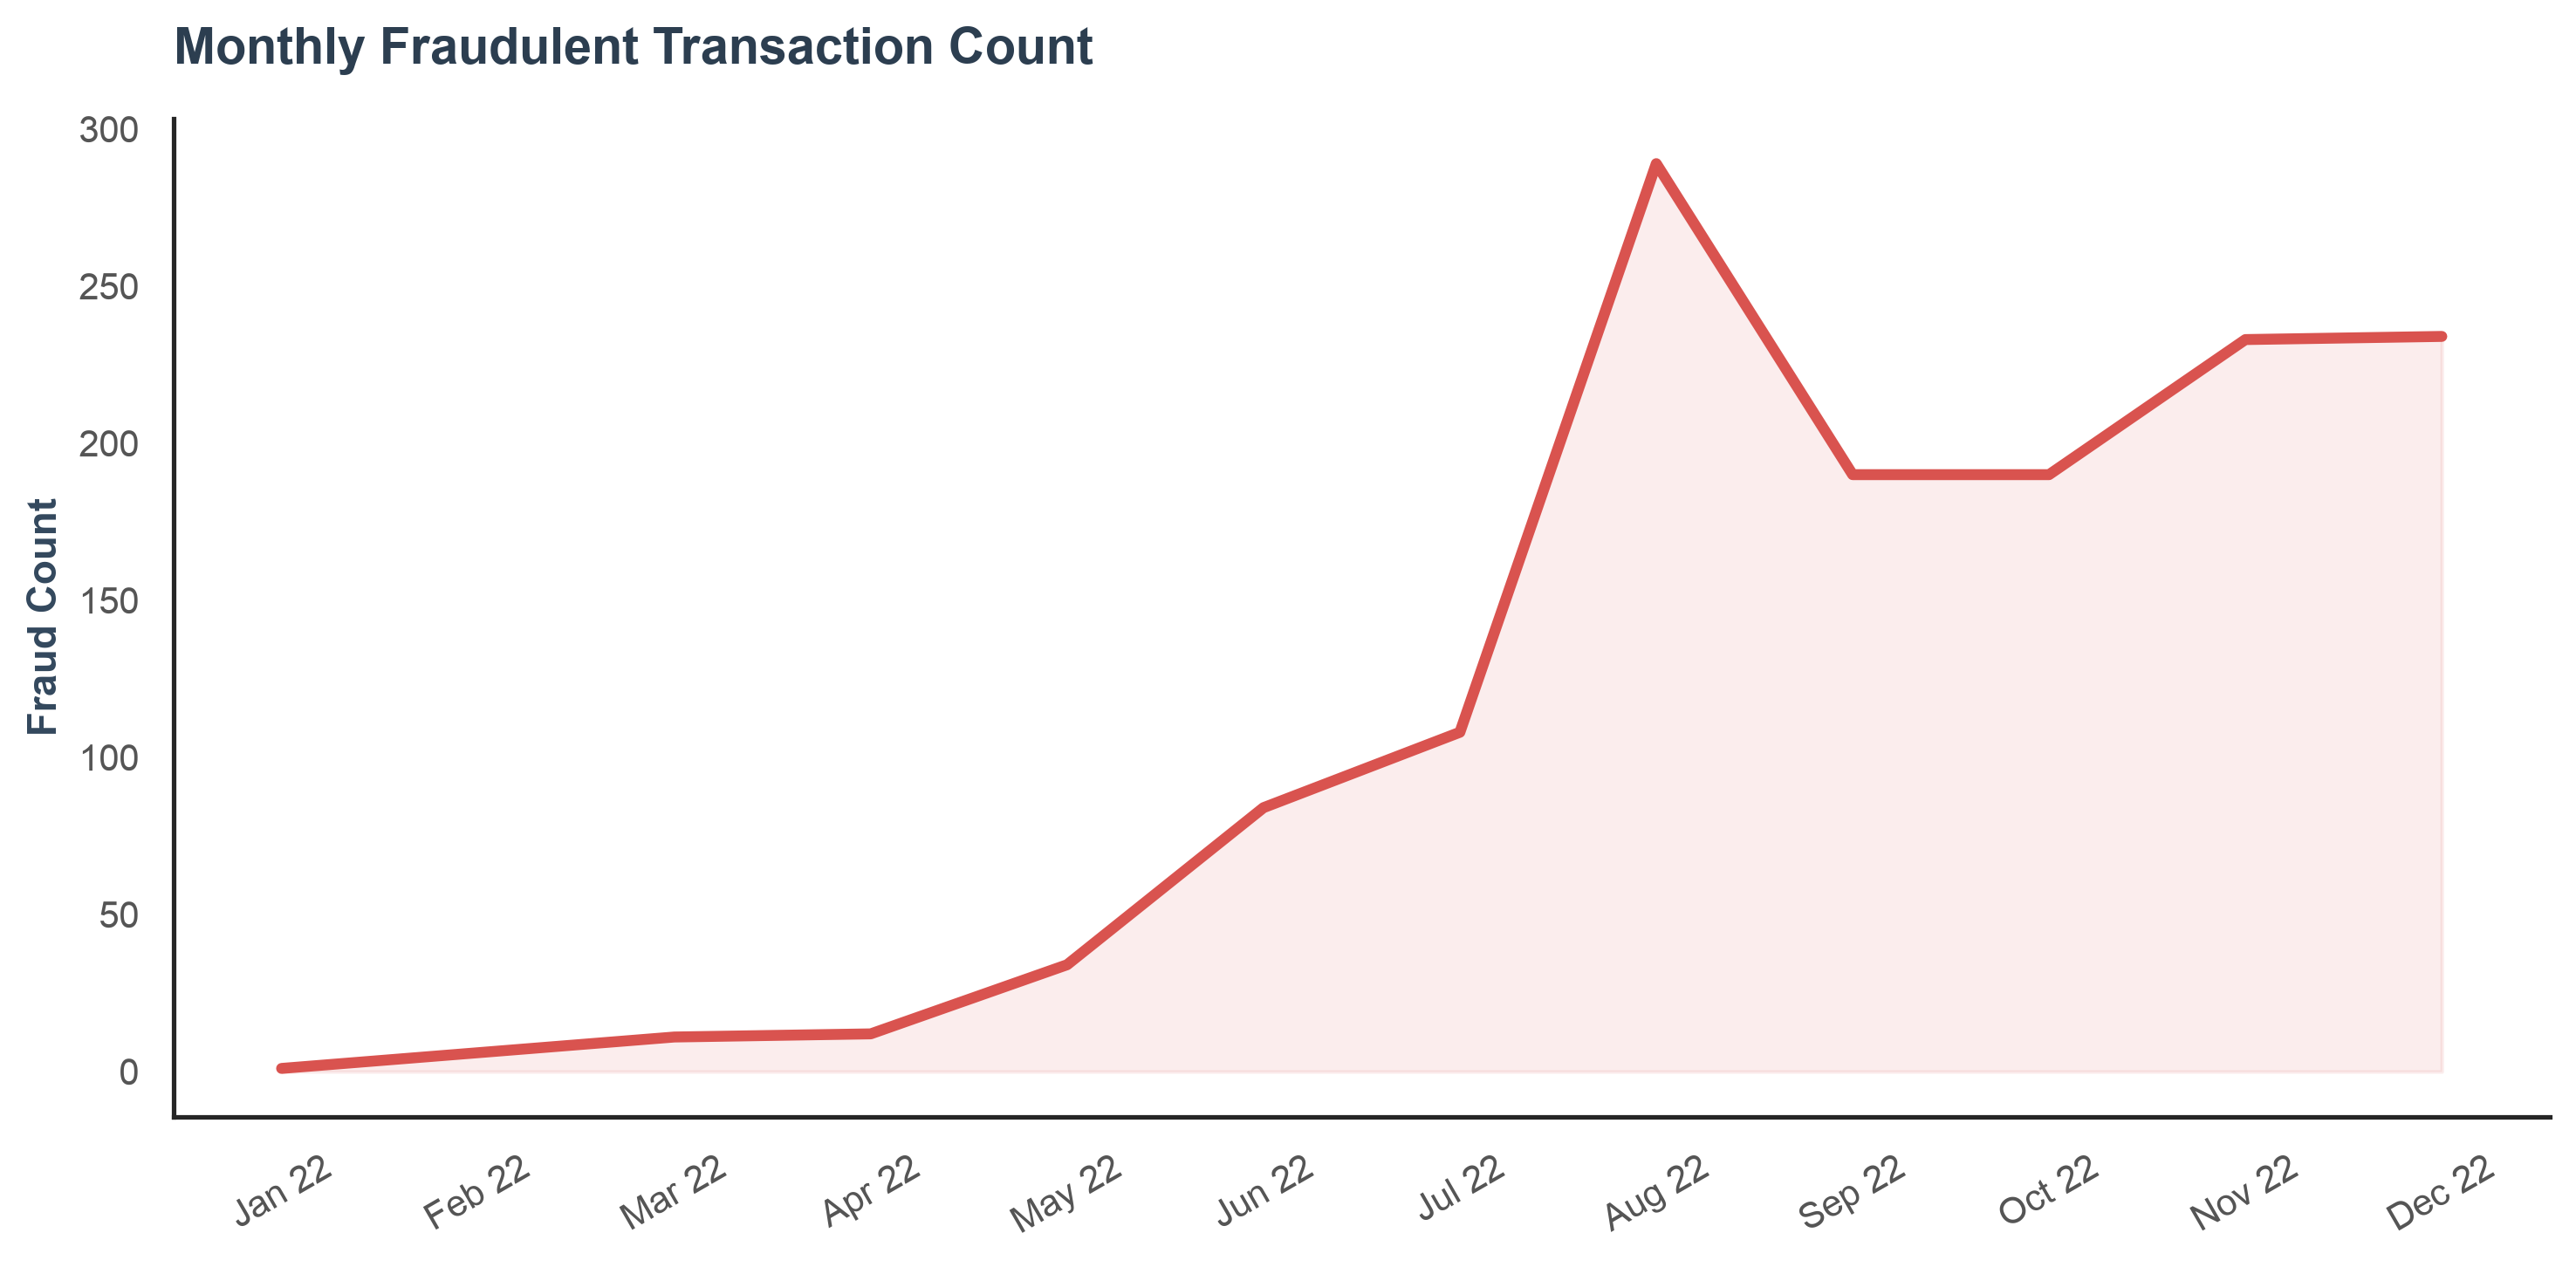

Saved: monthly_fraud_loss_euros.png


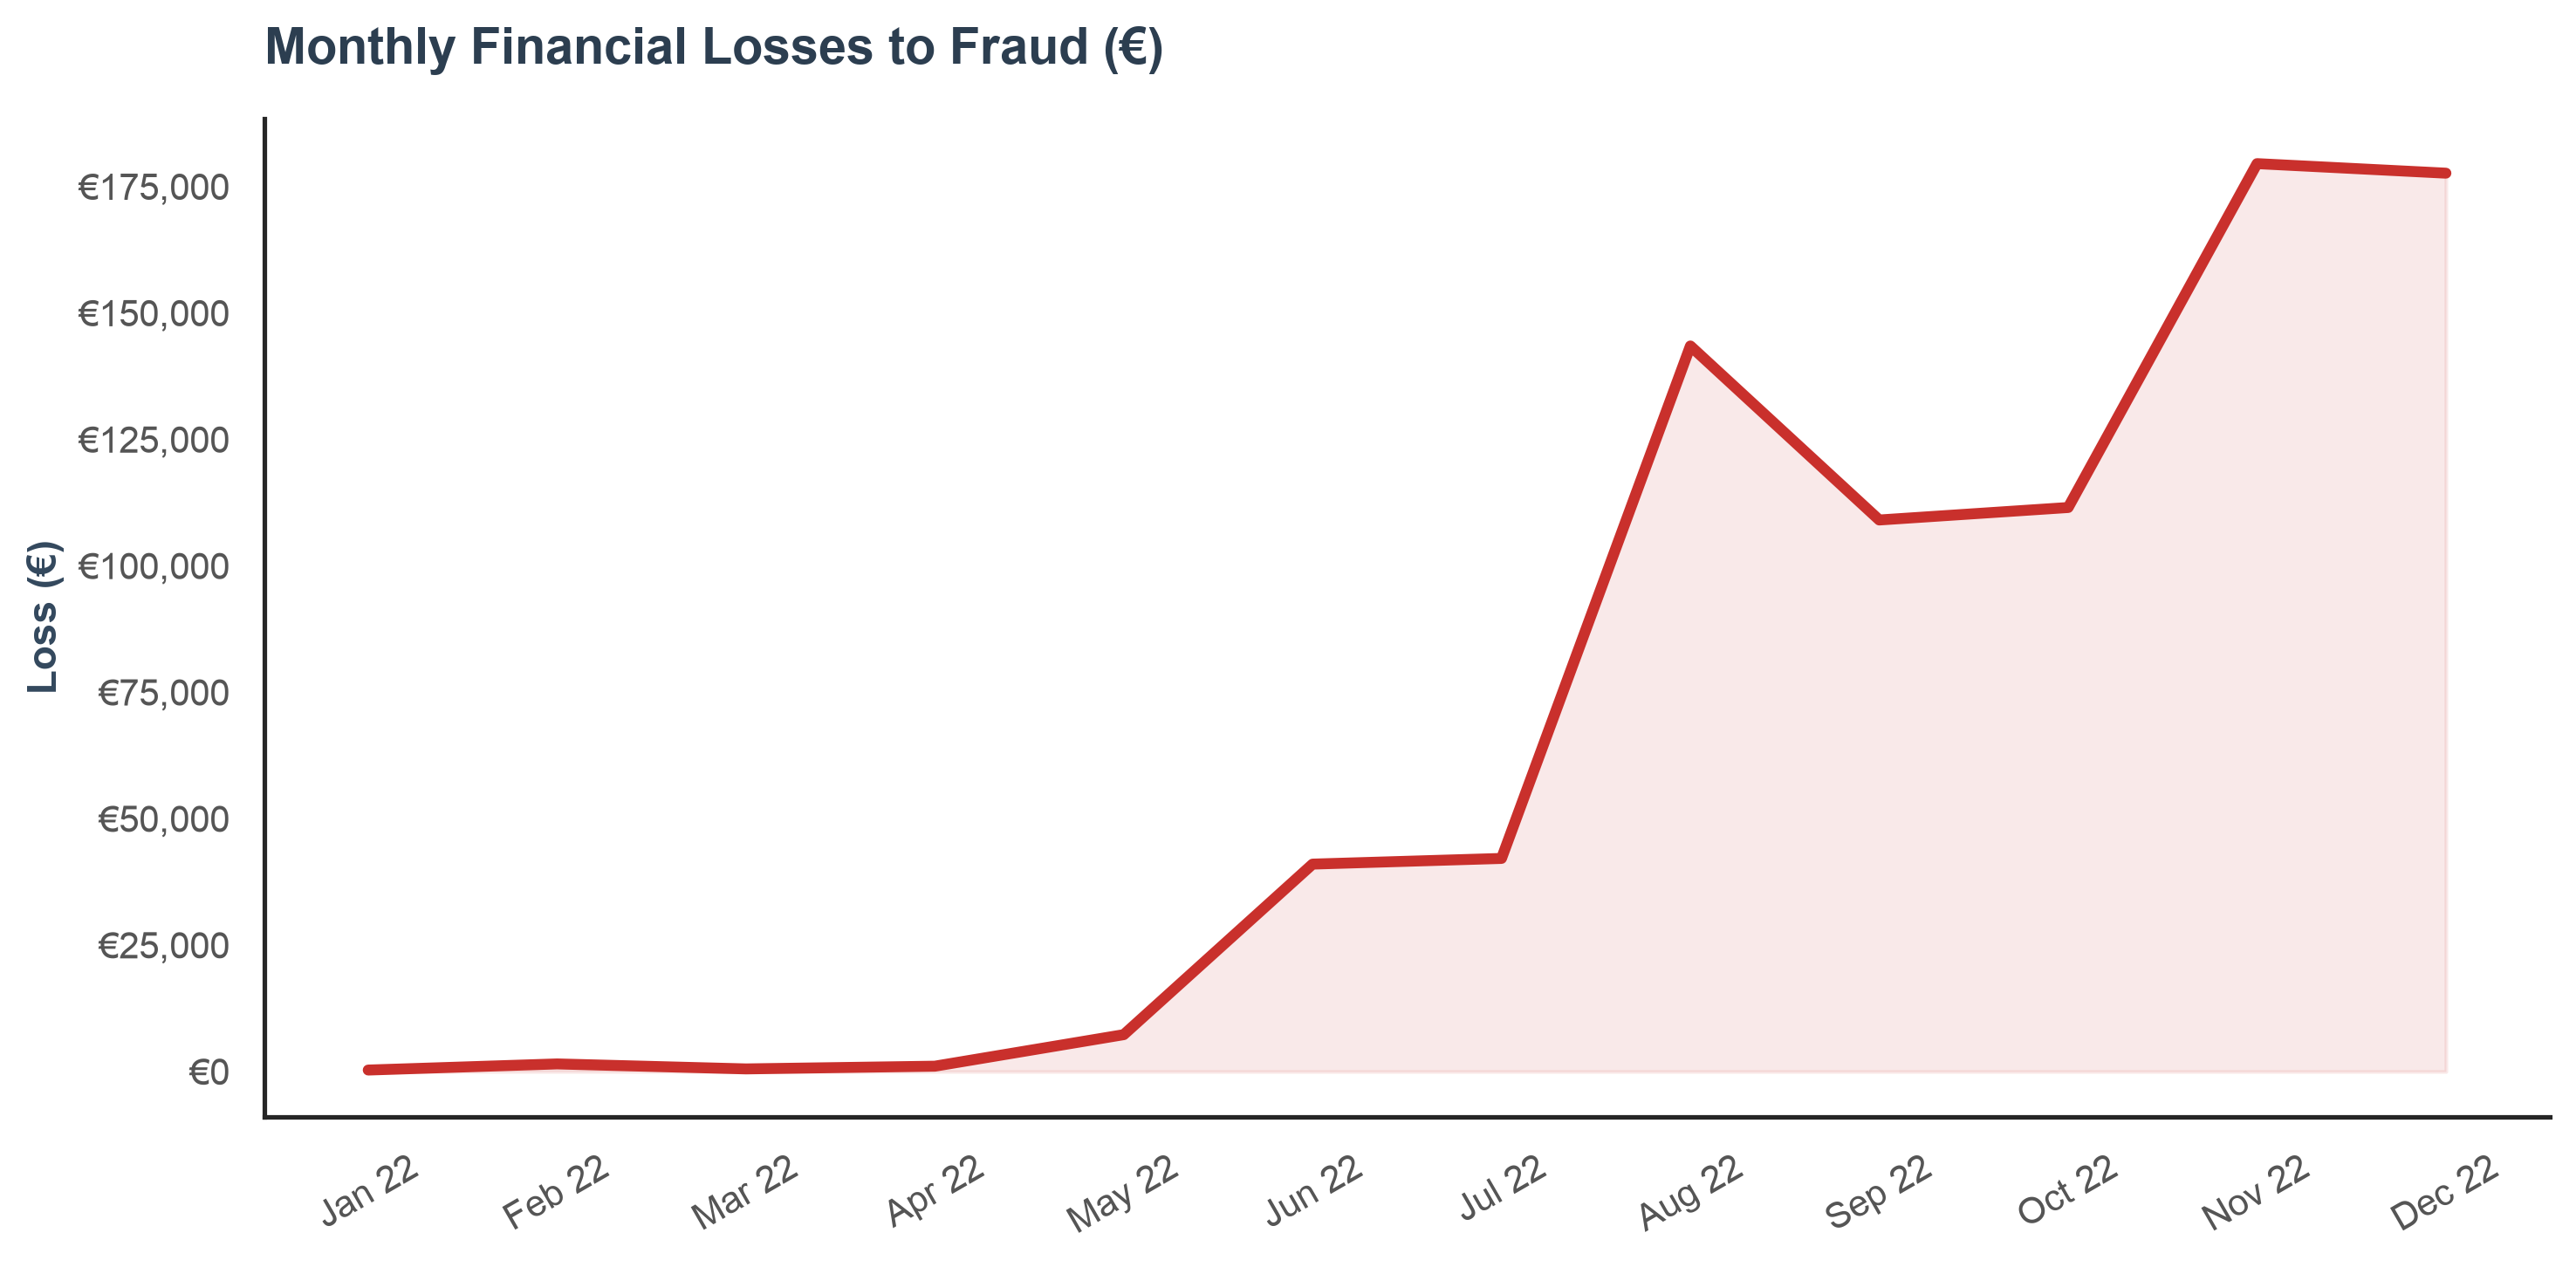

Saved: monthly_fraud_count_rate.png


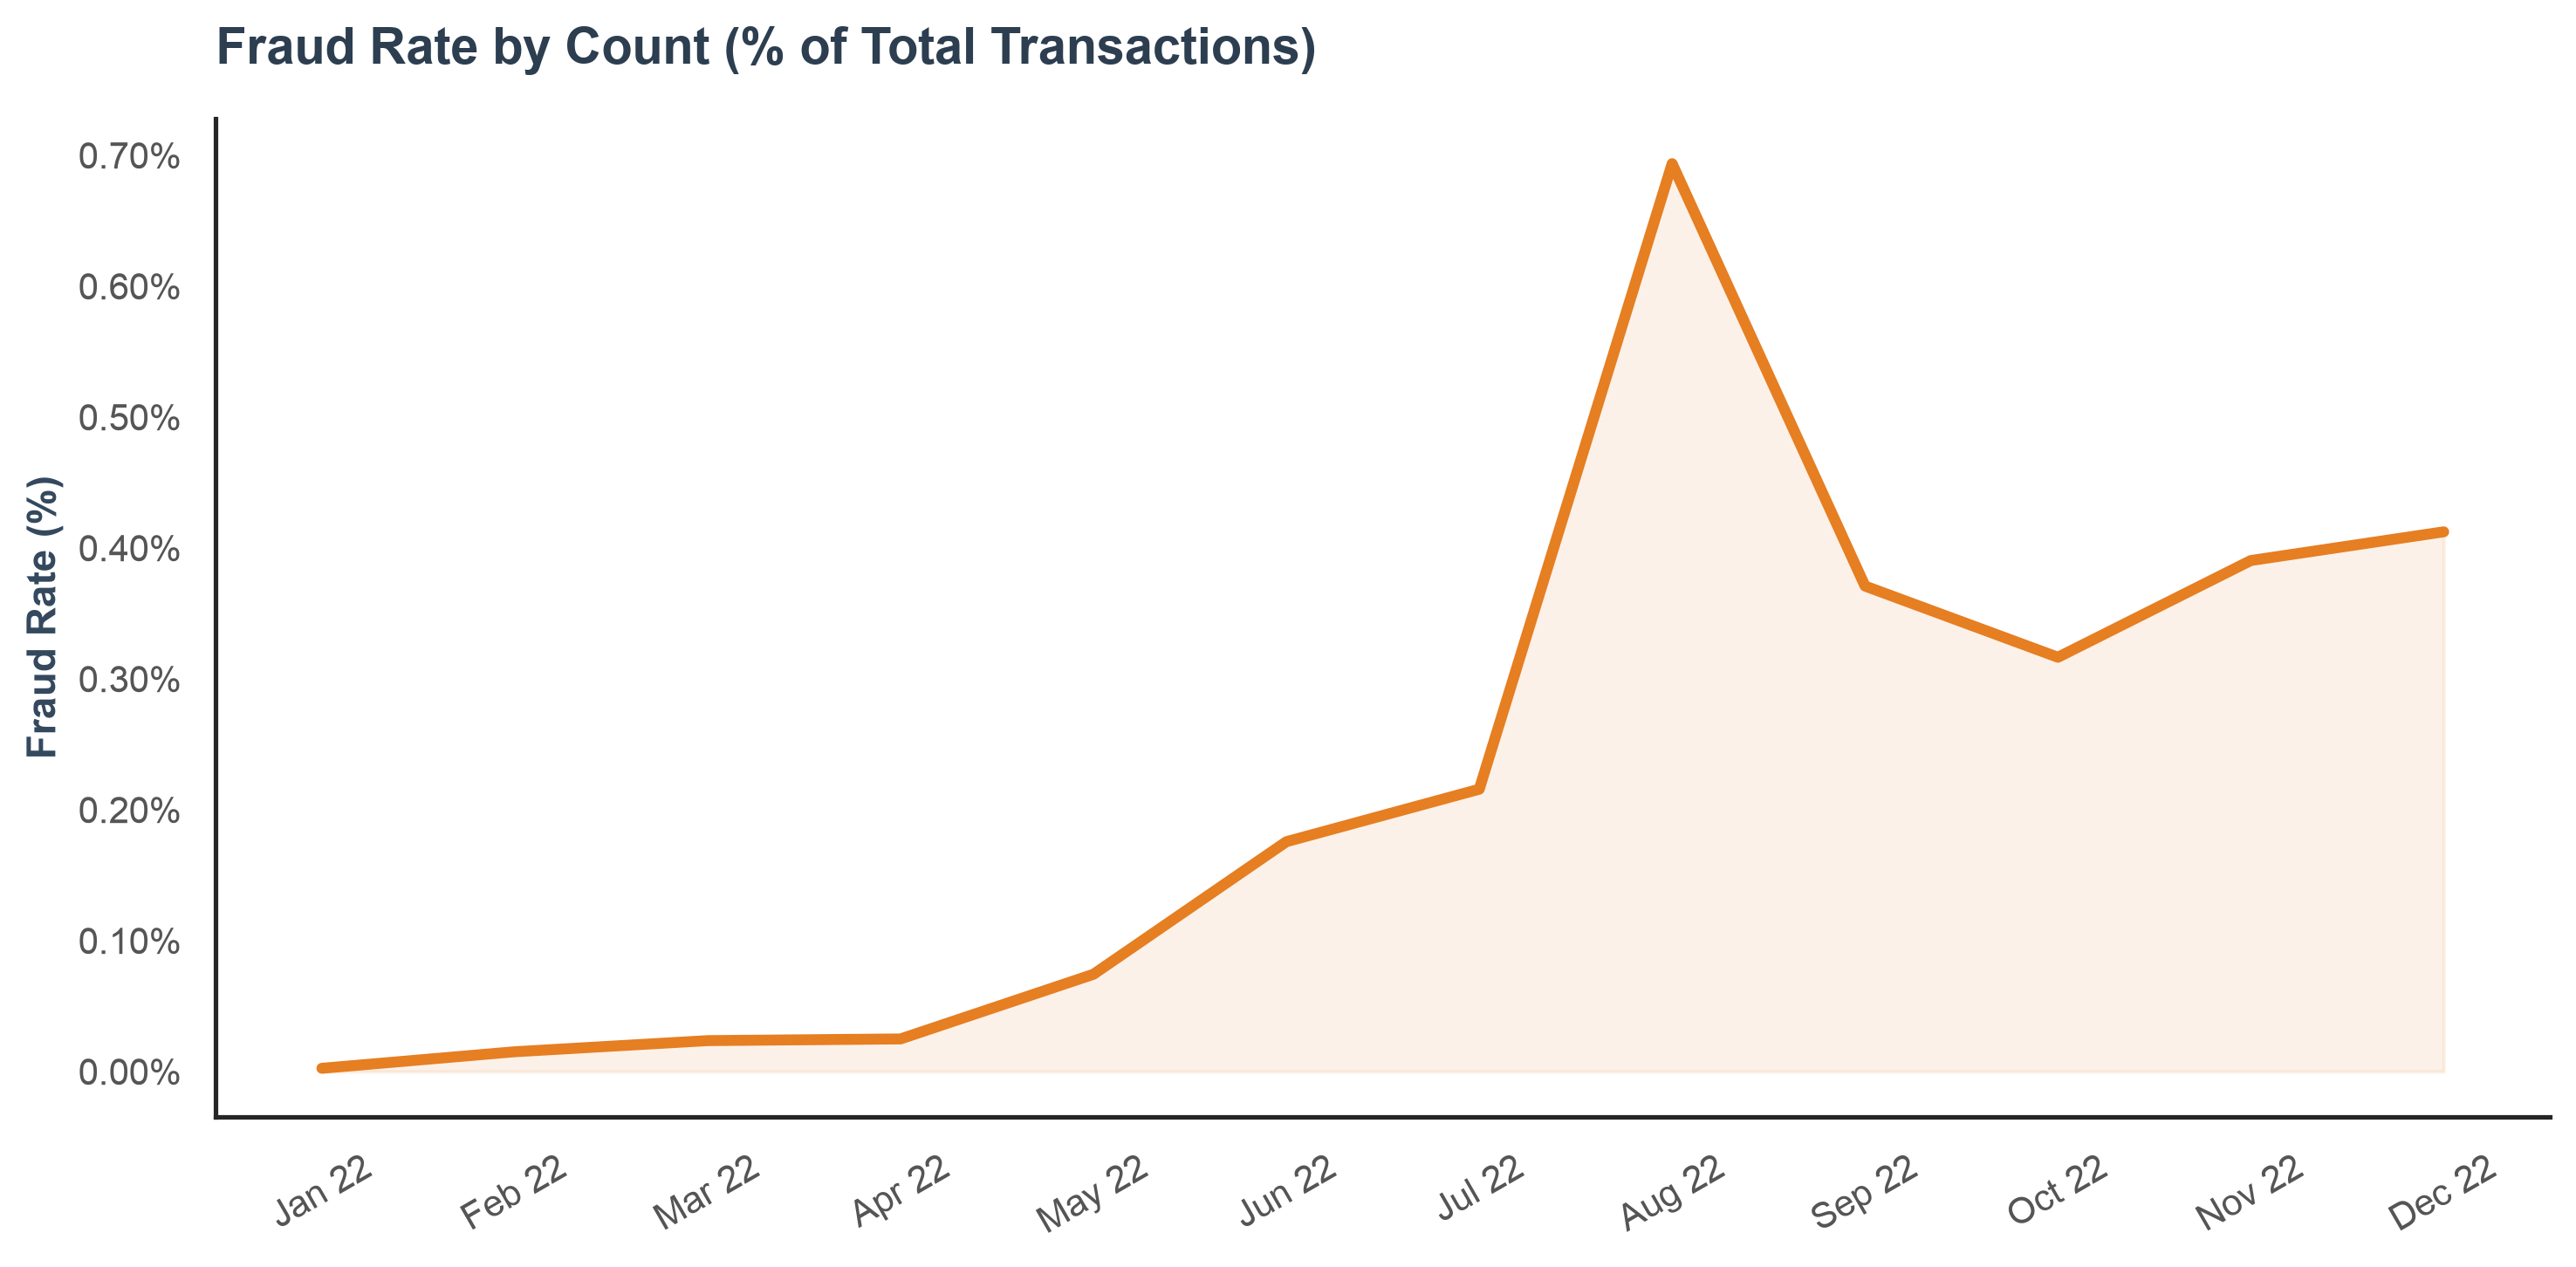

Saved: monthly_fraud_loss_rate.png


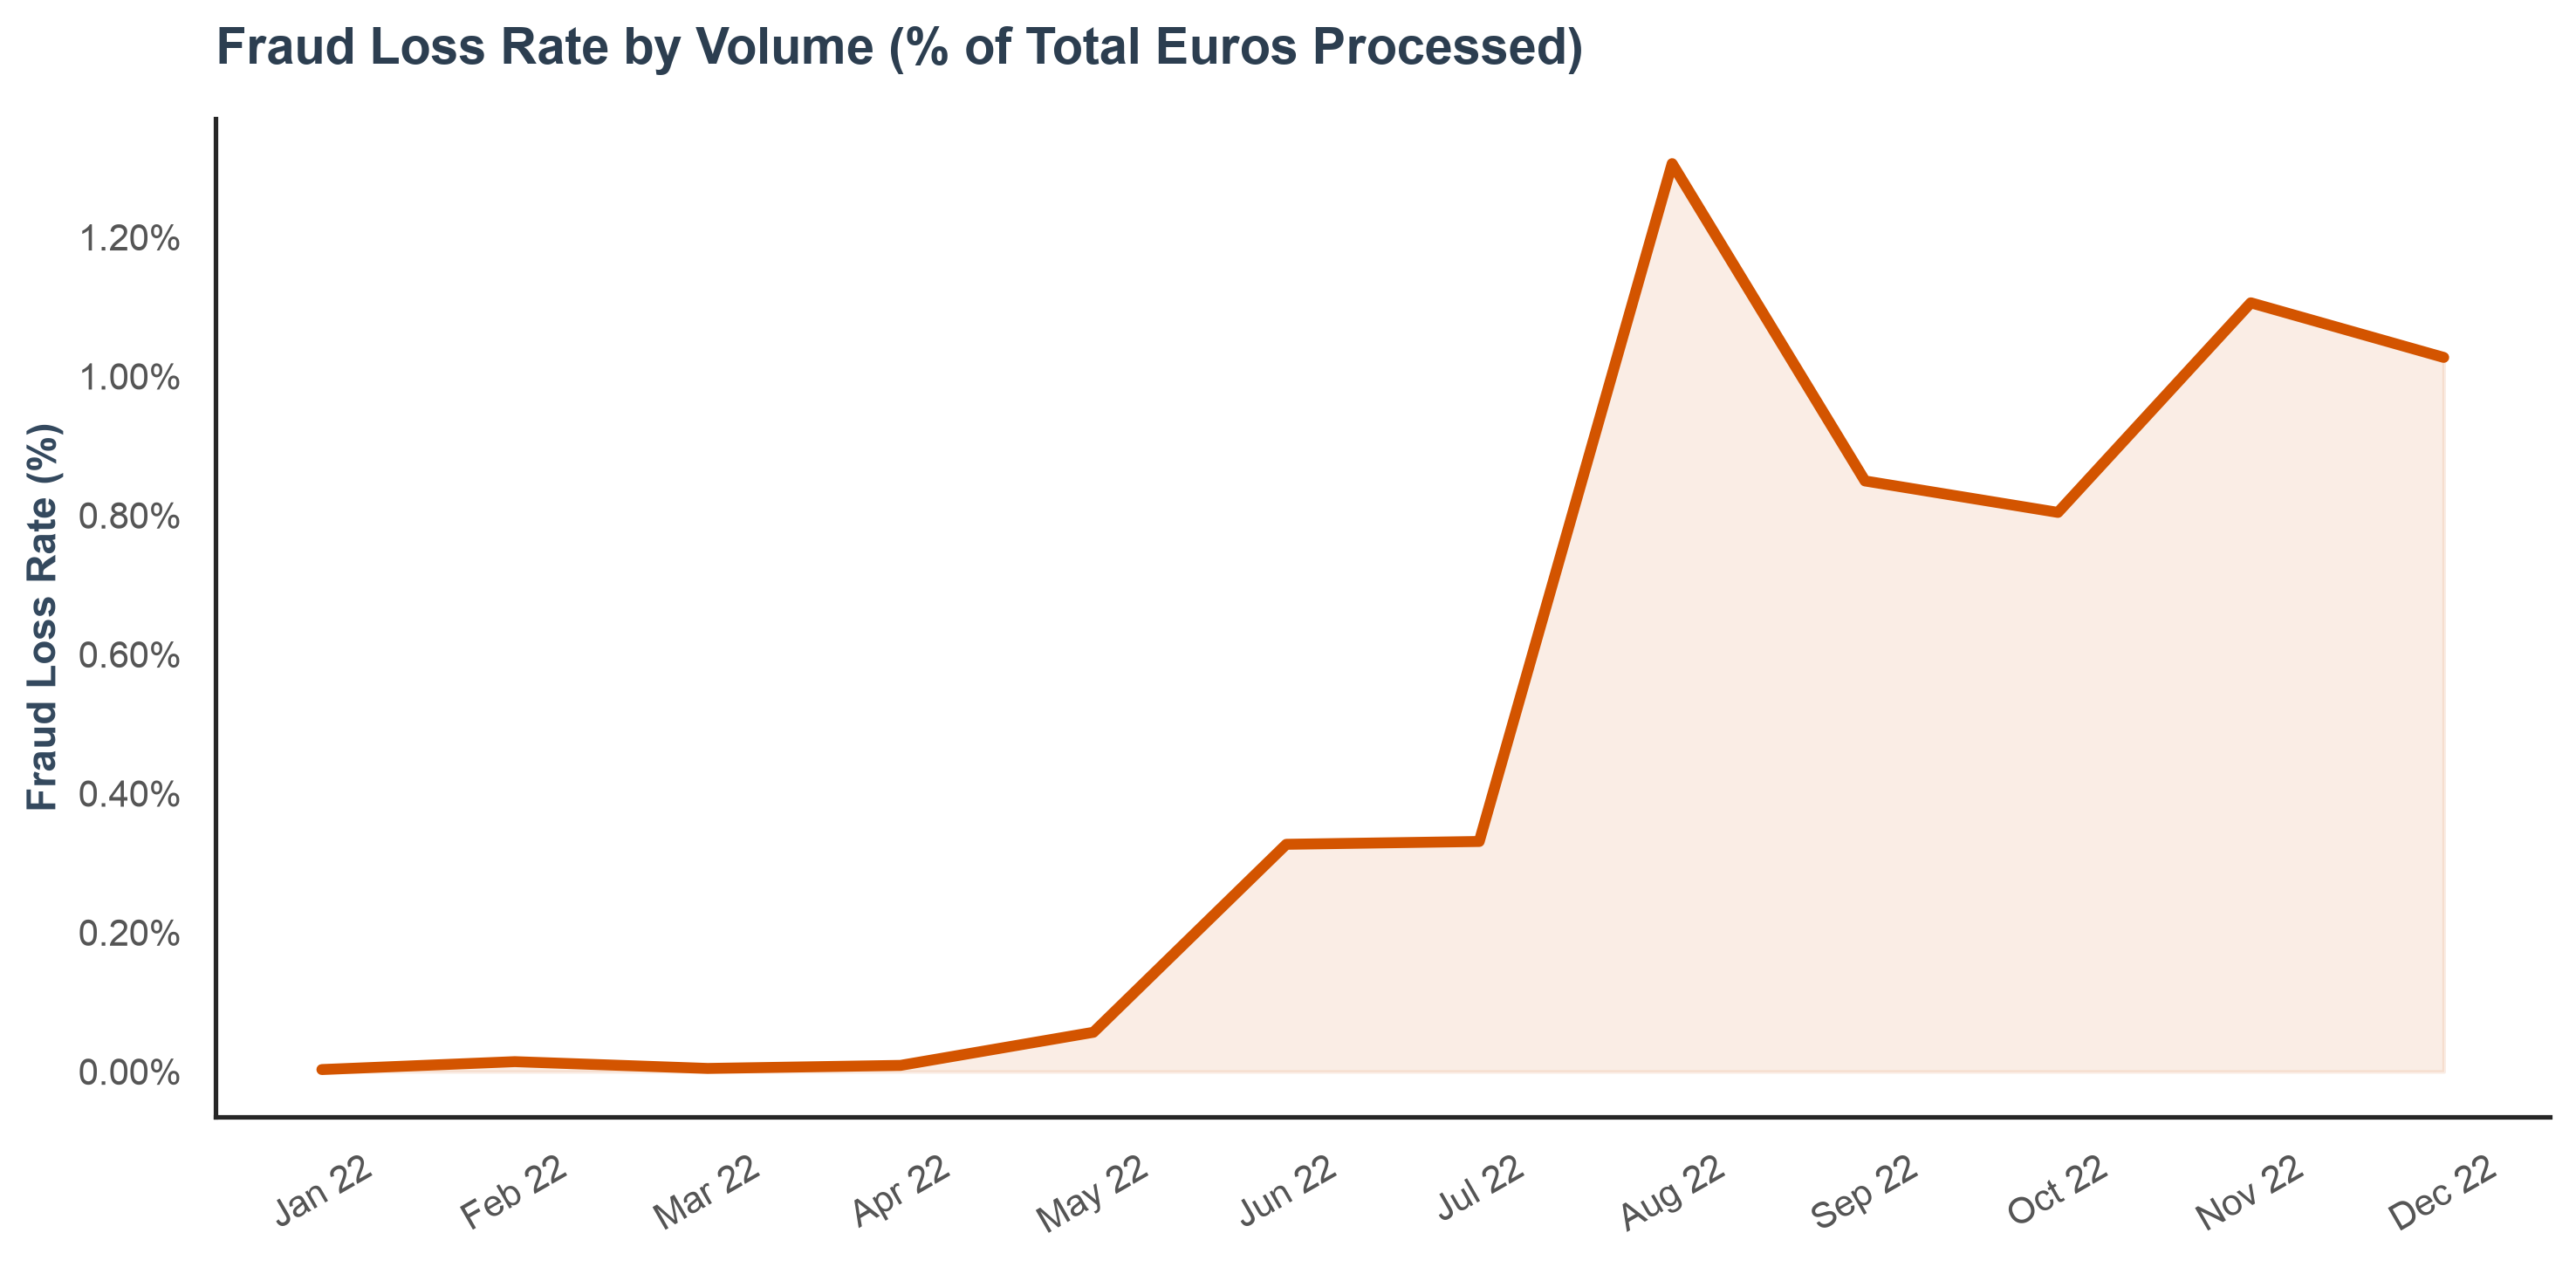

In [4]:
# -------------------------------------------------------------------------
# PREPARATION: Clean X-Axis Month Names
# -------------------------------------------------------------------------
# Convert 'year_month_str' (e.g., '2022-01') into 'Jan 22' or 'Jan'
# If your column is string format:
if 'year_month_str' in monthly_df.columns:
    monthly_df['month_name'] = pd.to_datetime(monthly_df['year_month_str']).dt.strftime('%b %y')
    # If all data is from a single year, use '%b' for just "Jan", "Feb", etc.

# Apply a minimalist presentation theme globally
sns.set_theme(style='white')  # Removes grey background & gridlines by default

# Configuration for the 4 charts
charts_config = [
    {
        'filename': 'monthly_fraud_count.png',
        'y_col': 'fraud_tx',
        'title': 'Monthly Fraudulent Transaction Count',
        'ylabel': 'Fraud Count',
        'color': '#D9534F', # Warm Red
        'is_currency': False,
        'is_percent': False
    },
    {
        'filename': 'monthly_fraud_loss_euros.png',
        'y_col': 'fraud_amount',
        'title': 'Monthly Financial Losses to Fraud (€)',
        'ylabel': 'Loss (€)',
        'color': '#C9302C', # Deep Crimson
        'is_currency': True,
        'is_percent': False
    },
    {
        'filename': 'monthly_fraud_count_rate.png',
        'y_col': 'fraud_count_rate_%',
        'title': 'Fraud Rate by Count (% of Total Transactions)',
        'ylabel': 'Fraud Rate (%)',
        'color': '#E67E22', # Orange
        'is_currency': False,
        'is_percent': True
    },
    {
        'filename': 'monthly_fraud_loss_rate.png',
        'y_col': 'fraud_loss_rate_%',
        'title': 'Fraud Loss Rate by Volume (% of Total Euros Processed)',
        'ylabel': 'Fraud Loss Rate (%)',
        'color': '#D35400', # Rust Orange
        'is_currency': False,
        'is_percent': True
    }
]

# -------------------------------------------------------------------------
# GENERATE & SAVE 4 INDIVIDUAL PLOTS
# -------------------------------------------------------------------------
for cfg in charts_config:
    fig, ax = plt.subplots(figsize=(10, 5), dpi=300) # High DPI for crisp slide export
    
    # 1. Plot Smooth Clean Line (No Markers)
    sns.lineplot(
        data=monthly_df, 
        x='month_name', 
        y=cfg['y_col'], 
        ax=ax, 
        color=cfg['color'], 
        linewidth=3.0,
        sort=False
    )
    
    # VISUAL ENHANCEMENT: Soft Gradient / Area Fill under the line
    ax.fill_between(
        range(len(monthly_df)), 
        monthly_df[cfg['y_col']], 
        color=cfg['color'], 
        alpha=0.10
    )
    
    # 2. Styling Headers & Axes
    ax.set_title(cfg['title'], fontsize=14, fontweight='bold', pad=15, loc='left', color='#2C3E50')
    ax.set_xlabel('', fontsize=10) # Removed explicit "Month" label for cleaner executive look
    ax.set_ylabel(cfg['ylabel'], fontsize=11, fontweight='semibold', color='#34495E')
    
    # 3. Clean Spines (Remove Top, Right, and Left Borders)
    sns.despine(top=True, right=True, left=False, bottom=False)
    ax.grid(False) # Strict enforcement: No gridlines
    
    # 4. Format X and Y Ticks
    ax.tick_params(axis='x', rotation=30, labelsize=10, colors='#555555')
    ax.tick_params(axis='y', labelsize=10, colors='#555555')
    
    # 5. Format Y-Axis numbers (Adding € or % signs automatically)
    if cfg['is_currency']:
        ax.yaxis.set_major_formatter('€{x:,.0f}')
    elif cfg['is_percent']:
        ax.yaxis.set_major_formatter('{x:.2f}%')
        
    plt.tight_layout()
    
    # 6. Save image to local directory
    plt.savefig(cfg['filename'], bbox_inches='tight', transparent=False, facecolor='white')
    print(f"Saved: {cfg['filename']}")
    
    plt.show()
    plt.close()

# Monthly average transaction mount

Saved: monthly_average_transaction_amount.png


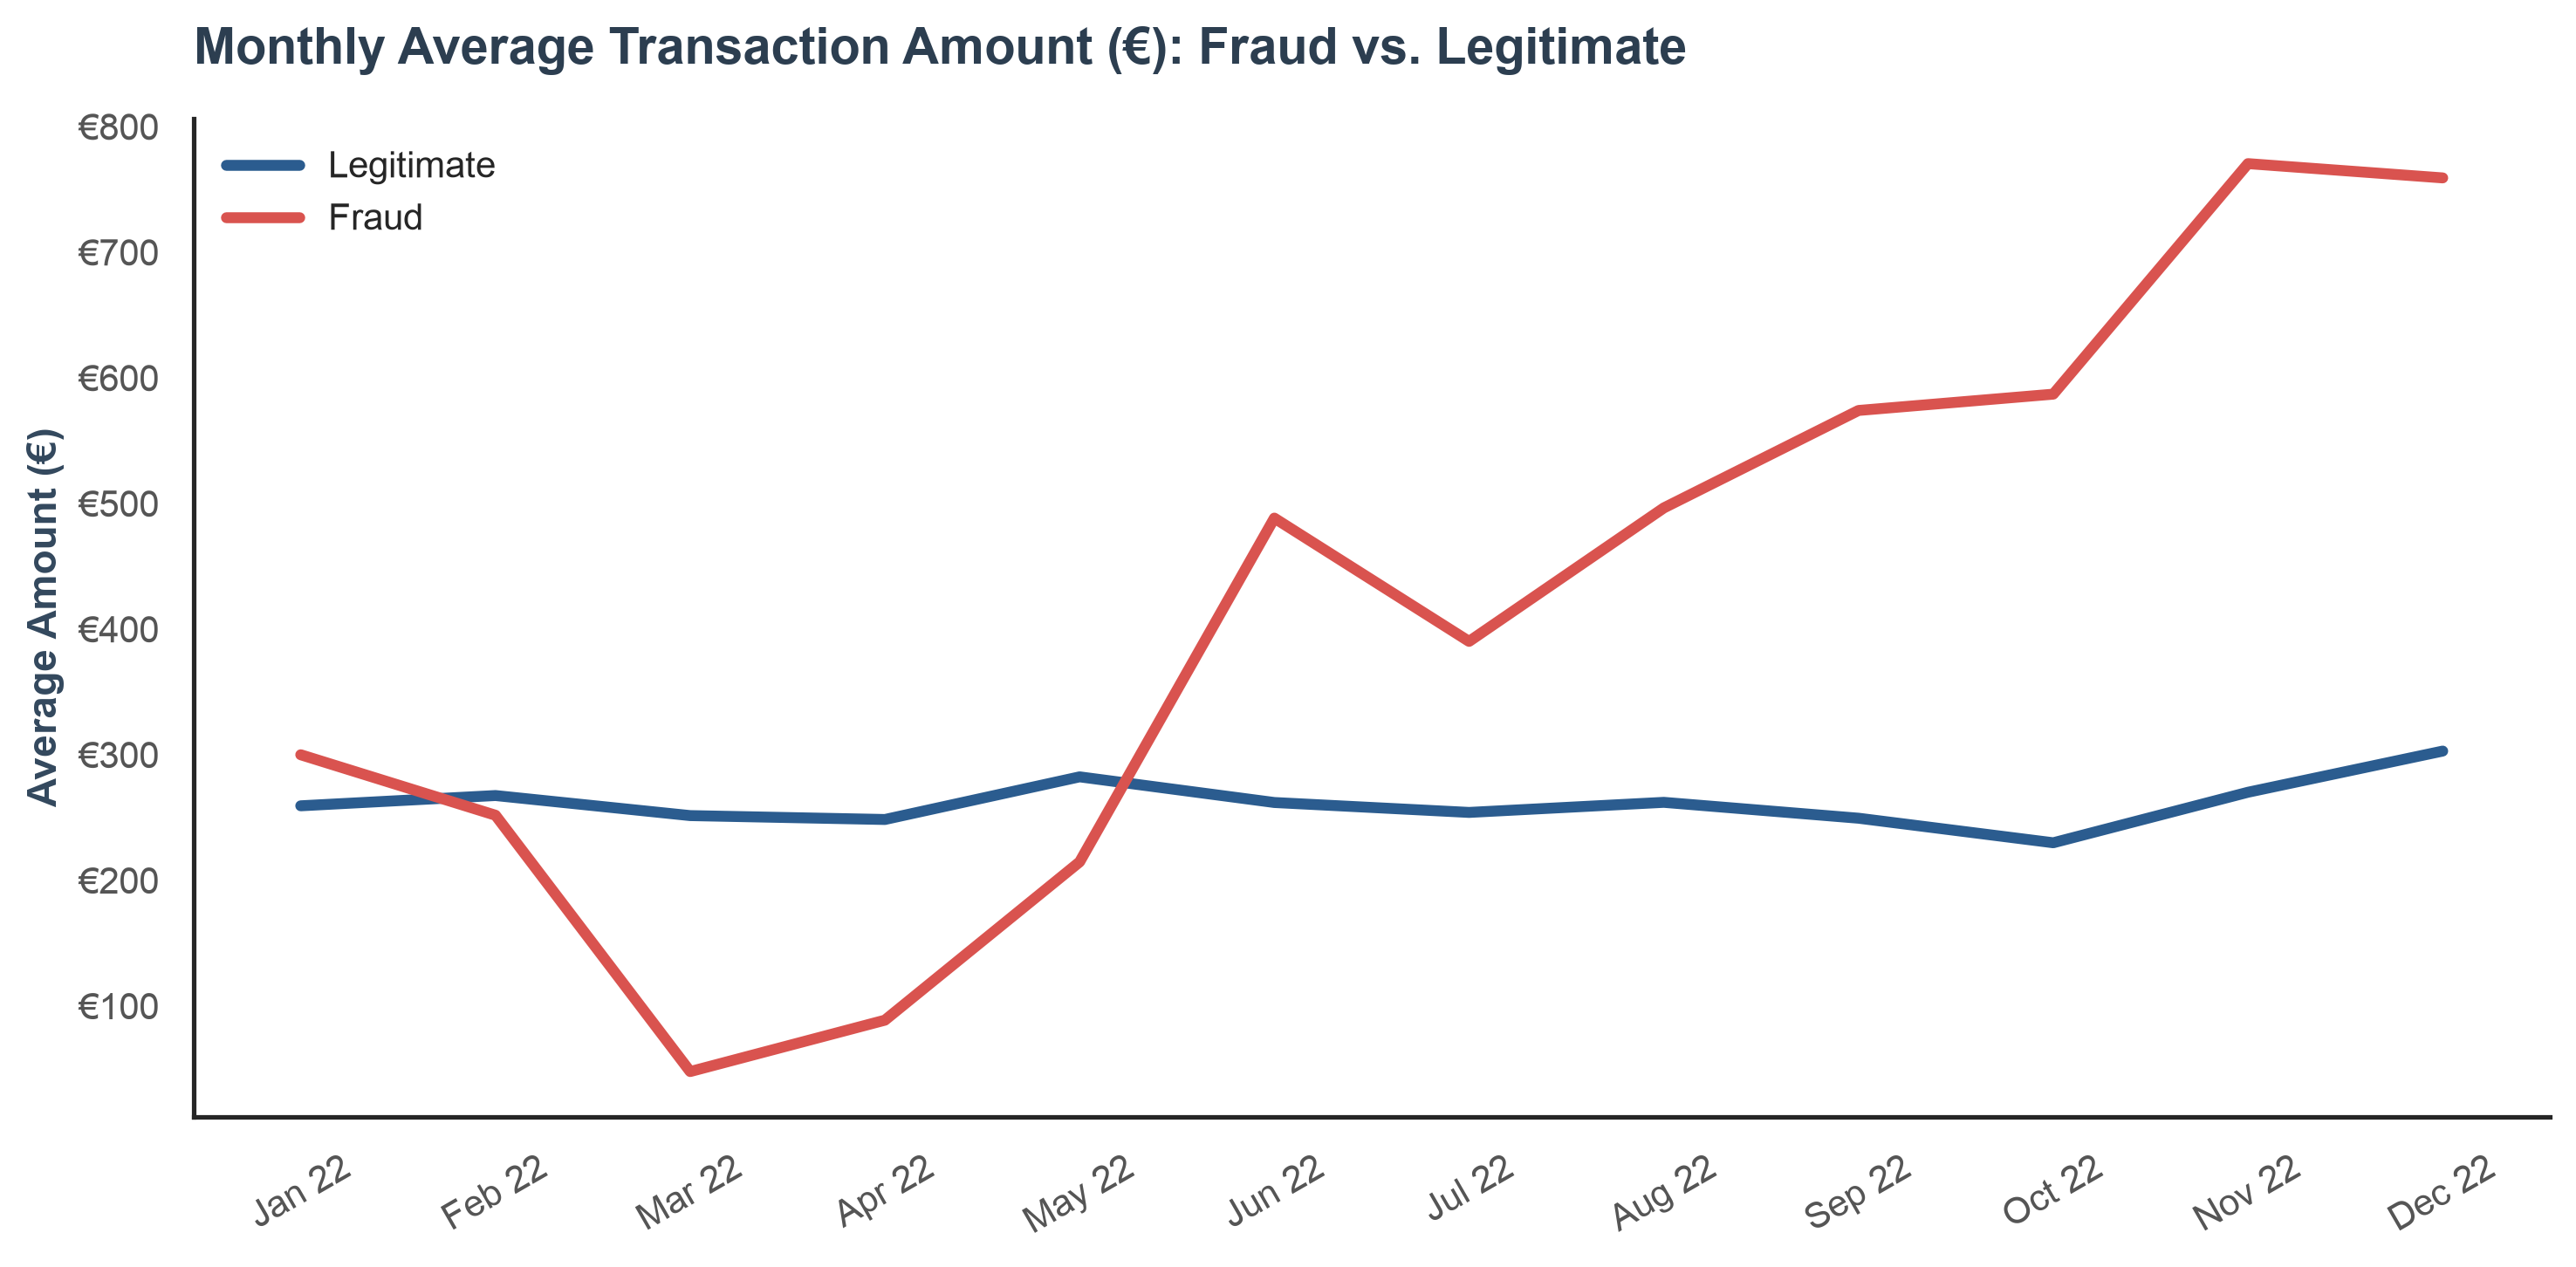

In [ ]:
# Calculate monthly average ticket size
monthly_avg_df = df.groupby(['year_month', 'is_fraud']).agg(
    avg_amount=('movement_amount_euros', 'mean')
).reset_index()

monthly_avg_df['year_month_str'] = monthly_avg_df['year_month'].astype(str)

# Convert 'year_month_str' (e.g., '2022-01') into 'Jan 22' or 'Jan'
# If your column is string format:
if 'year_month_str' in monthly_df.columns:
    monthly_df['month_name'] = pd.to_datetime(monthly_df['year_month_str']).dt.strftime('%b %y')
    # If all data is from a single year, use '%b' for just "Jan", "Feb", etc.

# Map is_fraud to readable labels
monthly_avg_df['Transaction Type'] = monthly_avg_df['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'})

# -------------------------------------------------------------------------
# PREPARATION: Clean X-Axis Month Names & Data Labels
# -------------------------------------------------------------------------
# Convert 'year_month' to datetime string format 'Jan 22'
monthly_avg_df['month_name'] = pd.to_datetime(monthly_avg_df['year_month'].astype(str)).dt.strftime('%b %y')

# Map is_fraud to readable labels
monthly_avg_df['Transaction Type'] = monthly_avg_df['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'})

# Apply global minimalist theme
sns.set_theme(style='white')

# -------------------------------------------------------------------------
# GENERATE & SAVE COMPARATIVE AVERAGE TRANSACTION SIZE PLOT
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# 1. Plot Smooth Lines (No Markers)
sns.lineplot(
    data=monthly_avg_df, 
    x='month_name', 
    y='avg_amount', 
    hue='Transaction Type',
    palette={'Legitimate': '#2B5C8F', 'Fraud': '#D9534F'}, # Deep Blue vs. Crimson
    linewidth=3.0,
    sort=False,
    ax=ax
)

# 2. Styling Headers & Axes
ax.set_title('Monthly Average Transaction Amount (€): Fraud vs. Legitimate', 
             fontsize=14, fontweight='bold', pad=15, loc='left', color='#2C3E50')
ax.set_xlabel('', fontsize=10) # Removed explicit "Month" label
ax.set_ylabel('Average Amount (€)', fontsize=11, fontweight='semibold', color='#34495E')

# 3. Clean Spines & Remove Gridlines
sns.despine(top=True, right=True, left=False, bottom=False)
ax.grid(False)

# 4. Format X and Y Ticks
ax.tick_params(axis='x', rotation=30, labelsize=10, colors='#555555')
ax.tick_params(axis='y', labelsize=10, colors='#555555')

# 5. Currency Formatting on Y-Axis
ax.yaxis.set_major_formatter('€{x:,.0f}')

# 6. Clean Custom Legend (Top Right, Frame off)
ax.legend(title='', frameon=False, fontsize=10, loc='upper left')

plt.tight_layout()

# 7. Save image to local directory
output_filename = 'monthly_average_transaction_amount.png'
plt.savefig(output_filename, bbox_inches='tight', transparent=False, facecolor='white')
print(f"Saved: {output_filename}")

plt.show()
plt.close()

# Expert Rule

In [ ]:
# ==========================================
# EXPERT RULE - QUICK SCAN THROUGH CATEGORICAL FEATURES
# ==========================================

total_frauds = df['is_fraud'].sum()

print("--- 1. CATEGICAL FEATURES RECALL SCAN ---")
cat_cols = ['payment_method', 'reading_method_group_name', 'is_physical', 
            'member_role', 'price_plan_subgroup_at_time']

for col in cat_cols:
    if col in df.columns:
        stats = df.groupby(col).agg(
            total_tx=('is_fraud', 'count'),
            fraud_tx=('is_fraud', 'sum')
        )
        stats['recall_%'] = (stats['fraud_tx'] / total_frauds) * 100
        stats['precision_%'] = (stats['fraud_tx'] / stats['total_tx']) * 100
        
        # Display values catching >= 15% of total frauds
        top_val = stats[stats['recall_%'] >= 15].sort_values(by='recall_%', ascending=False)
        if not top_val.empty:
            print(f"\nFeature: {col}")
            print(top_val[['total_tx', 'fraud_tx', 'recall_%', 'precision_%']].round(2))

print("\n" + "="*50 + "\n")

print("--- 2. CROSS-BORDER RECALL SCAN ---")
df['is_cross_border'] = (df['legal_country'] != df['counterparty_country_code']).astype(int)
cb_stats = df.groupby('is_cross_border').agg(
    total_tx=('is_fraud', 'count'),
    fraud_tx=('is_fraud', 'sum')
)
cb_stats['recall_%'] = (cb_stats['fraud_tx'] / total_frauds) * 100
cb_stats['precision_%'] = (cb_stats['fraud_tx'] / cb_stats['total_tx']) * 100
print(cb_stats.round(2))

print("\n" + "="*50 + "\n")

print("--- 3. NUMERICAL THRESHOLD SCAN (AMOUNT & VELOCITY) ---")
# Testing simple intuitive thresholds
for amt in [50, 100, 200, 500]:
    cnt = df[(df['movement_amount_euros'] > amt) & (df['is_fraud'] == 1)].shape[0]
    rec = (cnt / total_frauds) * 100
    prec = (cnt / df[df['movement_amount_euros'] > amt].shape[0]) * 100 if df[df['movement_amount_euros'] > amt].shape[0] > 0 else 0
    print(f"Amount > €{amt:<3} -> Recall: {rec:.1f}% | Precision: {prec:.2f}%")

--- 1. CATEGICAL FEATURES RECALL SCAN ---

Feature: payment_method
                total_tx  fraud_tx  recall_%  precision_%
payment_method                                           
online            559597      1346      96.7         0.24

Feature: reading_method_group_name
                           total_tx  fraud_tx  recall_%  precision_%
reading_method_group_name                                           
VAD                          559597      1346      96.7         0.24

Feature: is_physical
             total_tx  fraud_tx  recall_%  precision_%
is_physical                                           
True           338658      1173     84.27         0.35
False          248645       219     15.73         0.09

Feature: member_role
             total_tx  fraud_tx  recall_%  precision_%
member_role                                           
owner          485142      1235     88.72         0.25

Feature: price_plan_subgroup_at_time
                             total_tx  fraud_tx  

In [ ]:
# ==========================================
# QUESTION 2A: MULTI-VARIABLE EXPERT RULES
# ==========================================

# Make sure cross-border flag exists
df['is_cross_border'] = (df['legal_country'] != df['counterparty_country_code']).astype(int)

# --- CANDIDATE RULE 1: Online + High Amount (€500+) ---
# Strategy: Focus on severe losses
rule_1 = (df['reading_method_group_name'] == 'VAD') & (df['movement_amount_euros'] > 500)

# --- CANDIDATE RULE 2: Online + Cross-Border + High Amount (€200+) ---
# Strategy: Broad coverage on high-ticket cross-border online payments
rule_2 = (df['reading_method_group_name'] == 'VAD') & (df['is_cross_border'] == 1) & (df['movement_amount_euros'] > 200)

# --- CANDIDATE RULE 3: Solo Basic Plan + Online Payment + Amount > €100 ---
# Strategy: Target top price plan vector (Solo Basic accounts for ~40% of fraud)
rule_3 = (df['price_plan_subgroup_at_time'] == 'solo_basic') & (df['reading_method_group_name'] == 'VAD') & (df['movement_amount_euros'] > 100)

# --- CANDIDATE RULE 4: High Velocity Burst + Online Payment ---
# Strategy: Catch fast consecutive payments (time_settled_diff < 120s)
rule_4 = (df['reading_method_group_name'] == 'VAD') & (df['time_settled_diff'] < 120) & (df['movement_amount_euros'] > 50)


# Run evaluation across all candidates
print("--------------------------------------------------")
evaluate_rule(df, rule_1, rule_name="Rule 1: VAD & Amount > €500")
print("--------------------------------------------------")
evaluate_rule(df, rule_2, rule_name="Rule 2: VAD & Cross-Border & Amount > €200")
print("--------------------------------------------------")
evaluate_rule(df, rule_3, rule_name="Rule 3: Solo Basic & VAD & Amount > €100")
print("--------------------------------------------------")
evaluate_rule(df, rule_4, rule_name="Rule 4: Velocity Burst (<2 min) & VAD")
print("--------------------------------------------------")

--------------------------------------------------
=== RULE 1: VAD & AMOUNT > €500 ===
Rule Condition         : None
Total Alerts           : 90,440 (15.40% of all tx)
Alerts / Week          : 1739.2
Frauds Caught (TP)     : 786 / 1,392
Precision              : 0.87%
Recall                 : 56.47% (Target: >= 30%)
--------------------------------------------------
=== RULE 2: VAD & CROSS-BORDER & AMOUNT > €200 ===
Rule Condition         : None
Total Alerts           : 205,504 (34.99% of all tx)
Alerts / Week          : 3952.0
Frauds Caught (TP)     : 1,065 / 1,392
Precision              : 0.52%
Recall                 : 76.51% (Target: >= 30%)
--------------------------------------------------
=== RULE 3: SOLO BASIC & VAD & AMOUNT > €100 ===
Rule Condition         : None
Total Alerts           : 48,696 (8.29% of all tx)
Alerts / Week          : 936.5
Frauds Caught (TP)     : 470 / 1,392
Precision              : 0.97%
Recall                 : 33.76% (Target: >= 30%)
--------------------

# Testing that data_set and test are the same

In [9]:
# Check if the files are identical
print(f"data_set.csv shape : {pd.read_csv('data_set.csv', sep=';').shape}")
print(f"test.csv shape     : {pd.read_csv('test.csv', sep=';').shape}")

# Check duplicate transaction IDs across both files
df_data = pd.read_csv('data_set.csv', sep=',')
df_test = pd.read_csv('test.csv', sep=',')

overlap = df_data['card_transaction_id'].isin(df_test['card_transaction_id']).sum()
print(f"Overlapping transaction IDs: {overlap:,} out of {len(df_data):,}")

data_set.csv shape : (587303, 1)
test.csv shape     : (587303, 1)
Overlapping transaction IDs: 587,303 out of 587,303


# Machine Learning model (XGBoost)

### 1. Preprocessing

In [10]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve

# 1. Load data
df_full = pd.read_csv('data_set.csv', sep=',')
df_full['time_settled'] = pd.to_datetime(df_full['time_settled'])

# Feature Engineering
df_full['hour'] = df_full['time_settled'].dt.hour
df_full['dayofweek'] = df_full['time_settled'].dt.dayofweek
df_full['is_weekend'] = df_full['dayofweek'].isin([5, 6]).astype(int)
df_full['is_cross_border'] = (df_full['legal_country'] != df_full['counterparty_country_code']).astype(int)

# One-Hot Encoding
cat_cols = ['member_role', 'price_plan_subgroup_at_time', 'card_level_name', 
            'payment_method', 'reading_method_group_name', 'local_amount_currency']

df_encoded = pd.get_dummies(df_full, columns=cat_cols, drop_first=True)

# Define Features and Target
exclude_cols = ['Unnamed: 0', 'card_transaction_id', 'card_id', 'time_settled', 'legal_country', 
                'counterparty_country_code', 'year_month', 'year_month_str', 'is_fraud']

feature_cols = [c for c in df_encoded.columns if c not in exclude_cols]

X = df_encoded[feature_cols]
y = df_encoded['is_fraud'].astype(int)

# Stratified 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Get corresponding raw metadata for test set (for Rule 4 evaluation)
test_indices = y_test.index
df_test = df_full.loc[test_indices]

print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")

Train size: 469,842 | Test size: 117,461


### 2. Prediction & Performances

In [11]:
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42
)

model.fit(X_train, y_train)

# Predict probabilities on HELD-OUT test set
y_probs_test = model.predict_proba(X_test)[:, 1]

# Find probability threshold for ~35% Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_test)
target_recall = 0.35
idx = np.where(recalls >= target_recall)[0][-1]
opt_threshold = thresholds[idx]

y_pred_test = (y_probs_test >= opt_threshold).astype(int)

# Evaluation Metrics
tp_ml = sum((y_pred_test == 1) & (y_test == 1))
fp_ml = sum((y_pred_test == 1) & (y_test == 0))
total_test_frauds = sum(y_test)

prec_ml = (tp_ml / (tp_ml + fp_ml)) * 100 if (tp_ml + fp_ml) > 0 else 0
rec_ml = (tp_ml / total_test_frauds) * 100

num_weeks_test = max((df_test['time_settled'].max() - df_test['time_settled'].min()).days / 7, 1)
alerts_per_week_ml = (tp_ml + fp_ml) / num_weeks_test

print("="*50)
print(f"=== XGBOOST MODEL ON HELD-OUT 20% TEST SET (Threshold: {opt_threshold:.4f}) ===")
print("="*50)
print(f"Test Set Frauds Caught : {tp_ml} / {total_test_frauds}")
print(f"Model Recall           : {rec_ml:.2f}%")
print(f"Model Precision        : {prec_ml:.2f}%")
print(f"Weekly Alert Volume    : {alerts_per_week_ml:.1f}")
print("="*50)

=== XGBOOST MODEL ON HELD-OUT 20% TEST SET (Threshold: 0.9951) ===
Test Set Frauds Caught : 98 / 278
Model Recall           : 35.25%
Model Precision        : 75.38%
Weekly Alert Volume    : 2.5


### 3. Comparison with the Expert Rule

In [12]:
# 3. Evaluate Rule 4 on HELD-OUT 20% Test Set & Build Comparison Benchmark
rule_4_test_cond = (df_test['reading_method_group_name'] == 'VAD') & (df_test['time_settled_diff'] < 120) & (df_test['movement_amount_euros'] > 50)
rule_alerts_test = df_test[rule_4_test_cond]

tp_rule = rule_alerts_test['is_fraud'].sum()
fp_rule = len(rule_alerts_test) - tp_rule
fn_rule = total_test_frauds - tp_rule  # Frauds missed

prec_rule = (tp_rule / len(rule_alerts_test)) * 100 if len(rule_alerts_test) > 0 else 0
rec_rule = (tp_rule / total_test_frauds) * 100
alerts_per_week_rule = len(rule_alerts_test) / num_weeks_test

# ML Model False Negatives
fn_ml = total_test_frauds - tp_ml

# Build Comparison Table
comparison_test_df = pd.DataFrame({
    'Metric': [
        'Recall (%)', 
        'Precision (%)', 
        'Weekly Alert Volume', 
        'False Positive Count (Legit Flagged)', 
        'False Negative Count (Frauds Missed)'
    ],
    'Expert Rule (Rule 4)': [
        f"{rec_rule:.2f}%", 
        f"{prec_rule:.2f}%", 
        f"{alerts_per_week_rule:.1f}", 
        f"{fp_rule:,}", 
        f"{fn_rule:,}"
    ],
    'ML Model (XGBoost)': [
        f"{rec_ml:.2f}%", 
        f"{prec_ml:.2f}%", 
        f"{alerts_per_week_ml:.1f}", 
        f"{fp_ml:,}", 
        f"{fn_ml:,}"
    ]
})

print("\n=== REAL DEFENSE BENCHMARK (20% HELD-OUT TEST SET) ===")
comparison_test_df


=== REAL DEFENSE BENCHMARK (20% HELD-OUT TEST SET) ===


,Metric,Expert Rule (Rule 4),ML Model (XGBoost)
0,Recall (%),39.93%,35.25%
1,Precision (%),1.86%,75.38%
2,Weekly Alert Volume,114.7,2.5
3,False Positive Count (Legit Flagged),"5,851",32
4,False Negative Count (Frauds Missed),167,180


### 4. Plots

Saved: precision_comparison.png


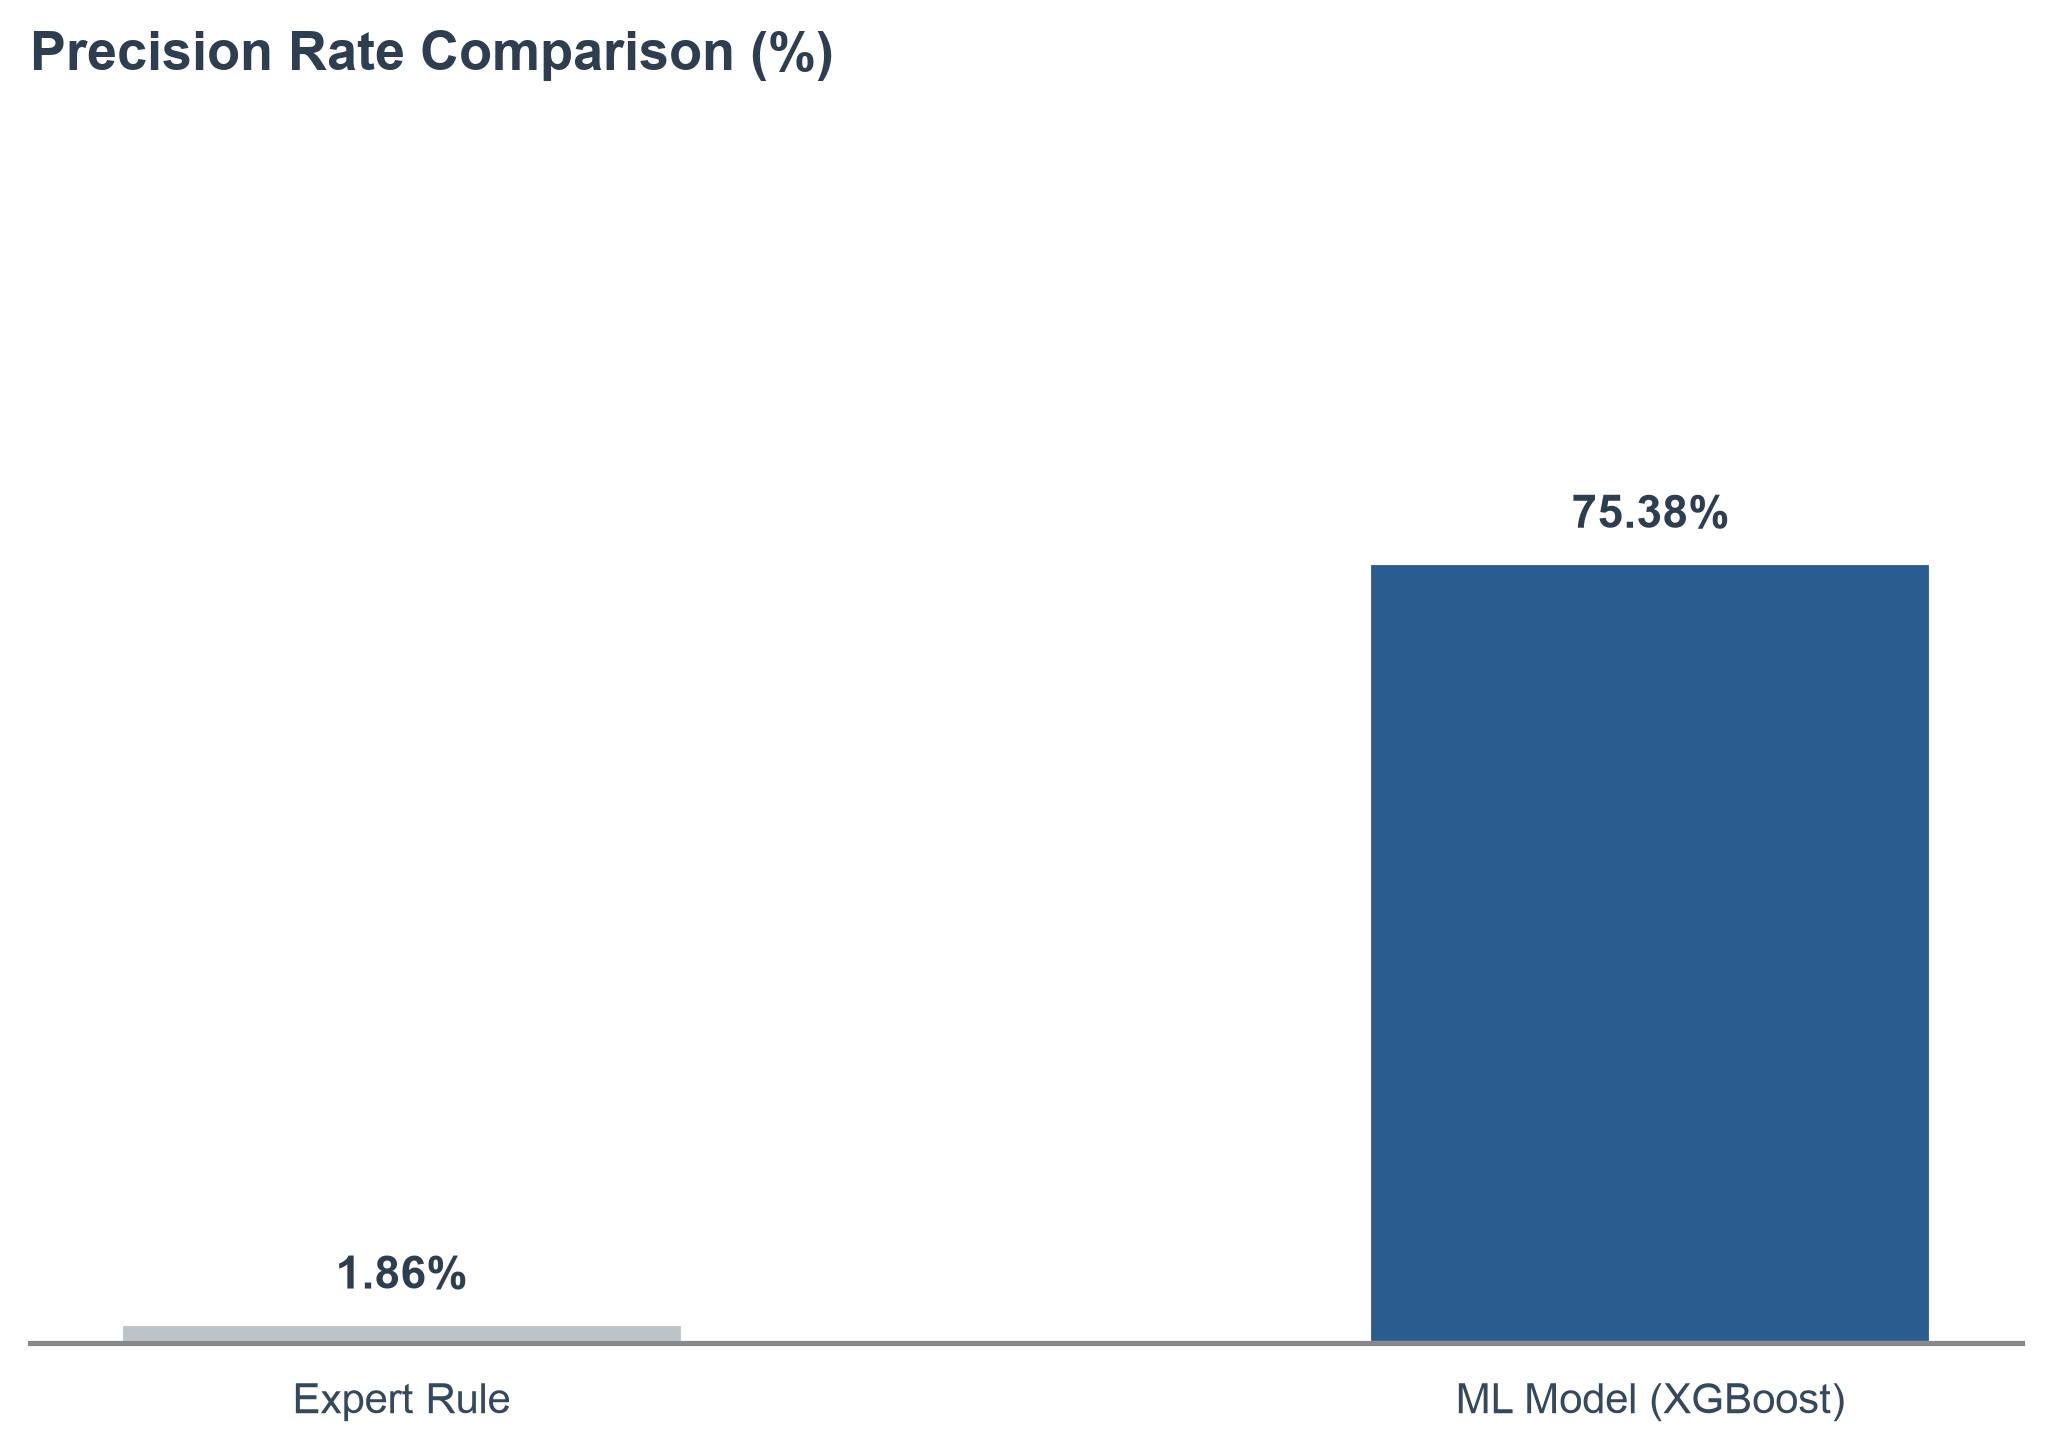

Saved: false_positives_comparison.png


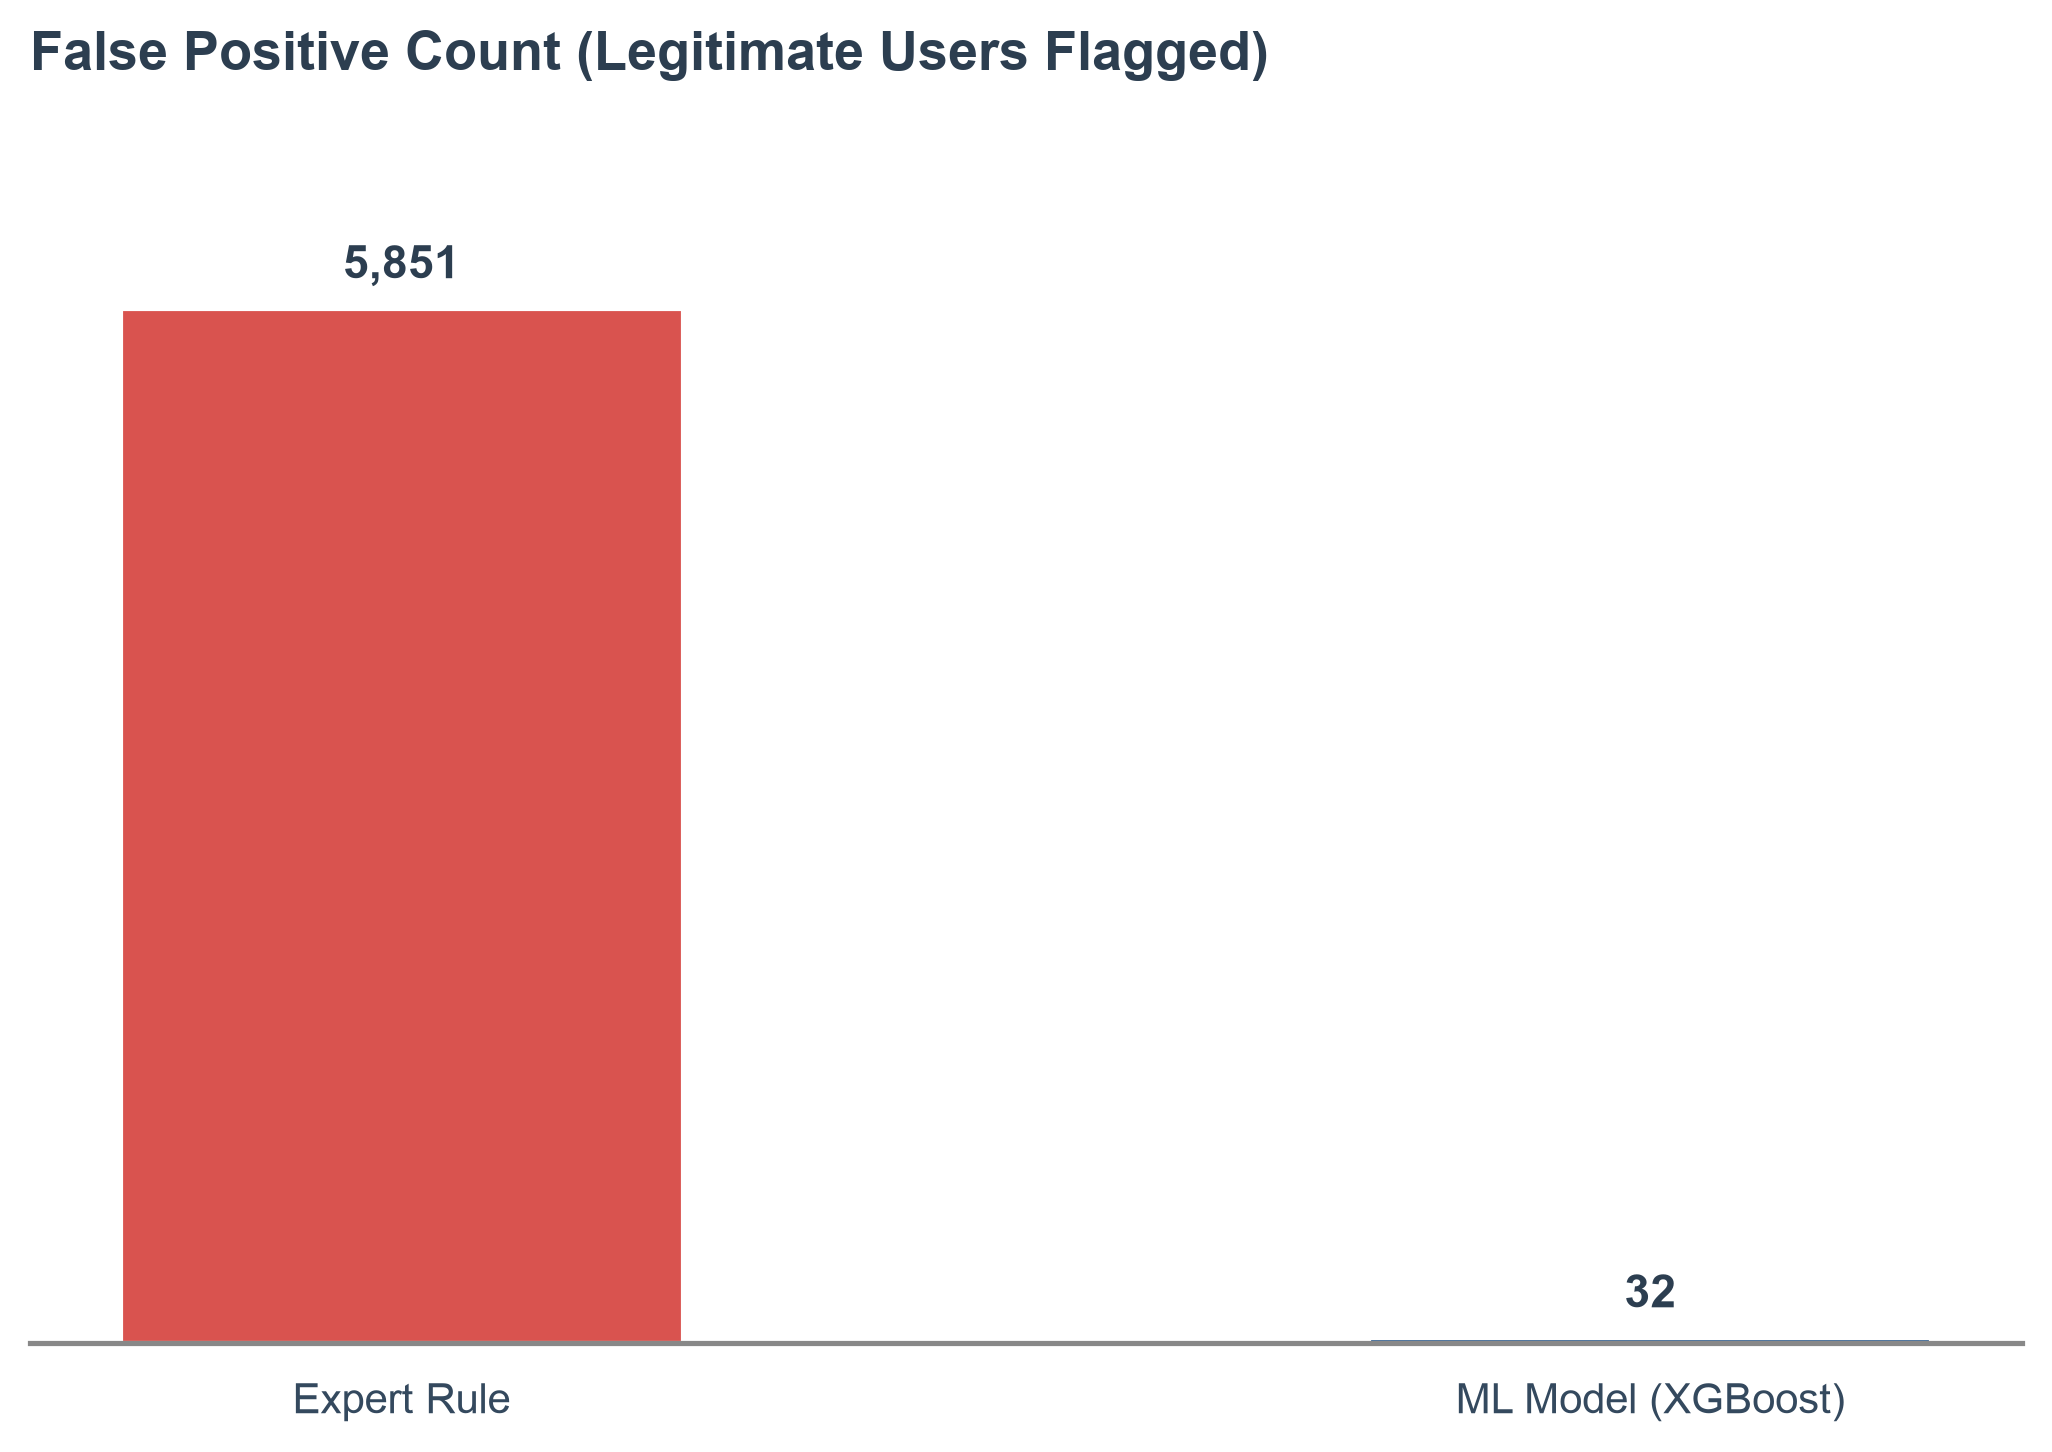

In [13]:
# Apply global minimalist theme
sns.set_theme(style='white')

# Data setup from your existing variables
methods = ['Expert Rule', 'ML Model (XGBoost)']
precision_values = [prec_rule, prec_ml]        # e.g. [1.86, 100.0]
fp_values = [fp_rule, fp_ml]                    # e.g. [5851, 0]

# -------------------------------------------------------------------------
# CHART 1: PRECISION COMPARISON (%)
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# Colors: Neutral Slate for Expert Rule, Vibrant Blue for ML Success
colors = ['#BDC3C7', '#2B5C8F']

bars = ax.bar(methods, precision_values, color=colors, width=0.45, zorder=2)

# Value annotations on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2., 
        height + 2.5, 
        f"{height:.2f}%", 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold', 
        color='#2C3E50',
        zorder=3
    )

# Header
ax.set_title('Precision Rate Comparison (%)', fontsize=13, fontweight='bold', pad=20, loc='left', color='#2C3E50')
ax.set_ylim(0, 115)  # Leave room for top labels

# Remove Gridlines & Y-Axis Completely
ax.grid(False)
sns.despine(top=True, right=True, left=True, bottom=False)

# Keep only the bottom X-axis line & clean ticks
ax.spines['bottom'].set_zorder(5)
ax.spines['bottom'].set_color('#888888')
ax.tick_params(axis='y', left=False, labelleft=False)
ax.tick_params(axis='x', labelsize=10, colors='#34495E')

plt.tight_layout()
plt.savefig('precision_comparison.png', bbox_inches='tight', dpi=300, facecolor='white')
print("Saved: precision_comparison.png")
plt.show()
plt.close()


# -------------------------------------------------------------------------
# CHART 2: FALSE POSITIVE COUNT COMPARISON (LEGIT USERS FLAGGED)
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# Colors: Crimson Warning Red for High False Positives, Slate Blue for 0 FP
colors = ['#D9534F', '#2B5C8F']

bars = ax.bar(methods, fp_values, color=colors, width=0.45, zorder=2)

# Value annotations on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2., 
        height + (max(fp_values) * 0.02 if max(fp_values) > 0 else 50), 
        f"{int(height):,}", 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold', 
        color='#2C3E50',
        zorder=3
    )

# Header
ax.set_title('False Positive Count (Legitimate Users Flagged)', fontsize=13, fontweight='bold', pad=20, loc='left', color='#2C3E50')
ax.set_ylim(0, max(fp_values) * 1.15 if max(fp_values) > 0 else 100)

# Remove Gridlines & Y-Axis Completely
ax.grid(False)
sns.despine(top=True, right=True, left=True, bottom=False)

# Keep only the bottom X-axis line & clean ticks
ax.spines['bottom'].set_zorder(5)
ax.spines['bottom'].set_color('#888888')
ax.tick_params(axis='y', left=False, labelleft=False)
ax.tick_params(axis='x', labelsize=10, colors='#34495E')

plt.tight_layout()
plt.savefig('false_positives_comparison.png', bbox_inches='tight', dpi=300, facecolor='white')
print("Saved: false_positives_comparison.png")
plt.show()
plt.close()

### 5. Key drivers (different designs)

/var/folders/fz/wq3679m55ljbqt9g587mqbph0000gn/T/ipykernel_31184/2179307905.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


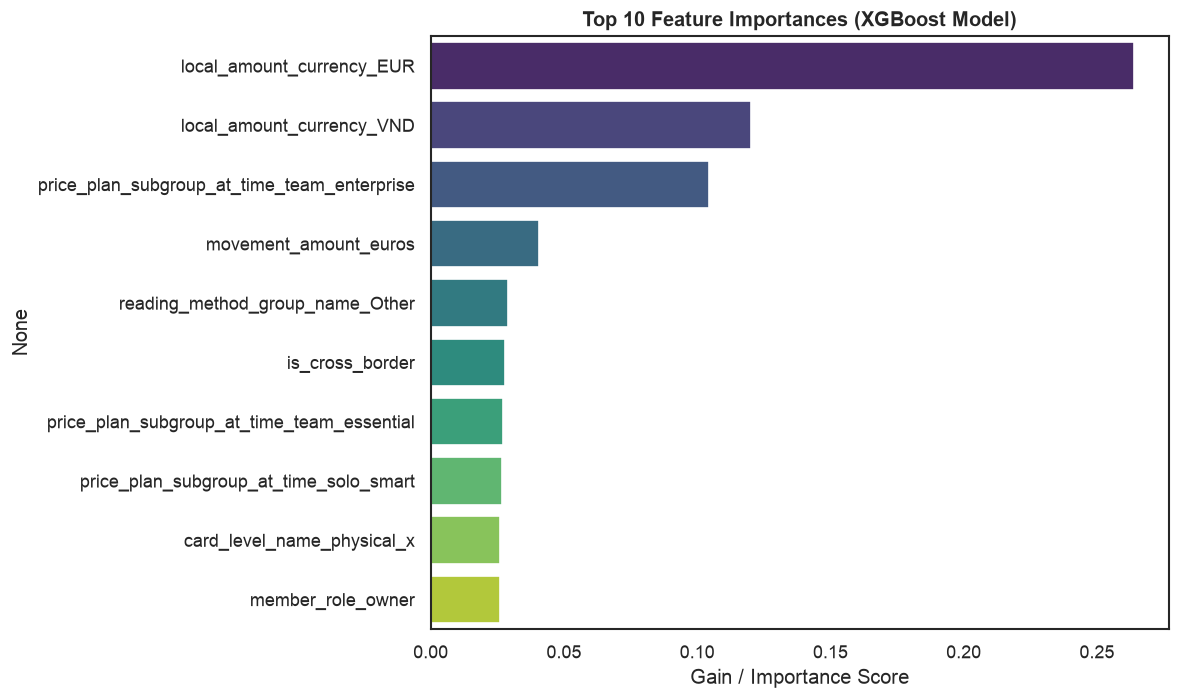

In [14]:
# Top 10 Feature Importances
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 10 Feature Importances (XGBoost Model)', fontsize=12, fontweight='bold')
plt.xlabel('Gain / Importance Score')
plt.tight_layout()
plt.show()

findfont: Failed to find font weight semibold, now using 700.


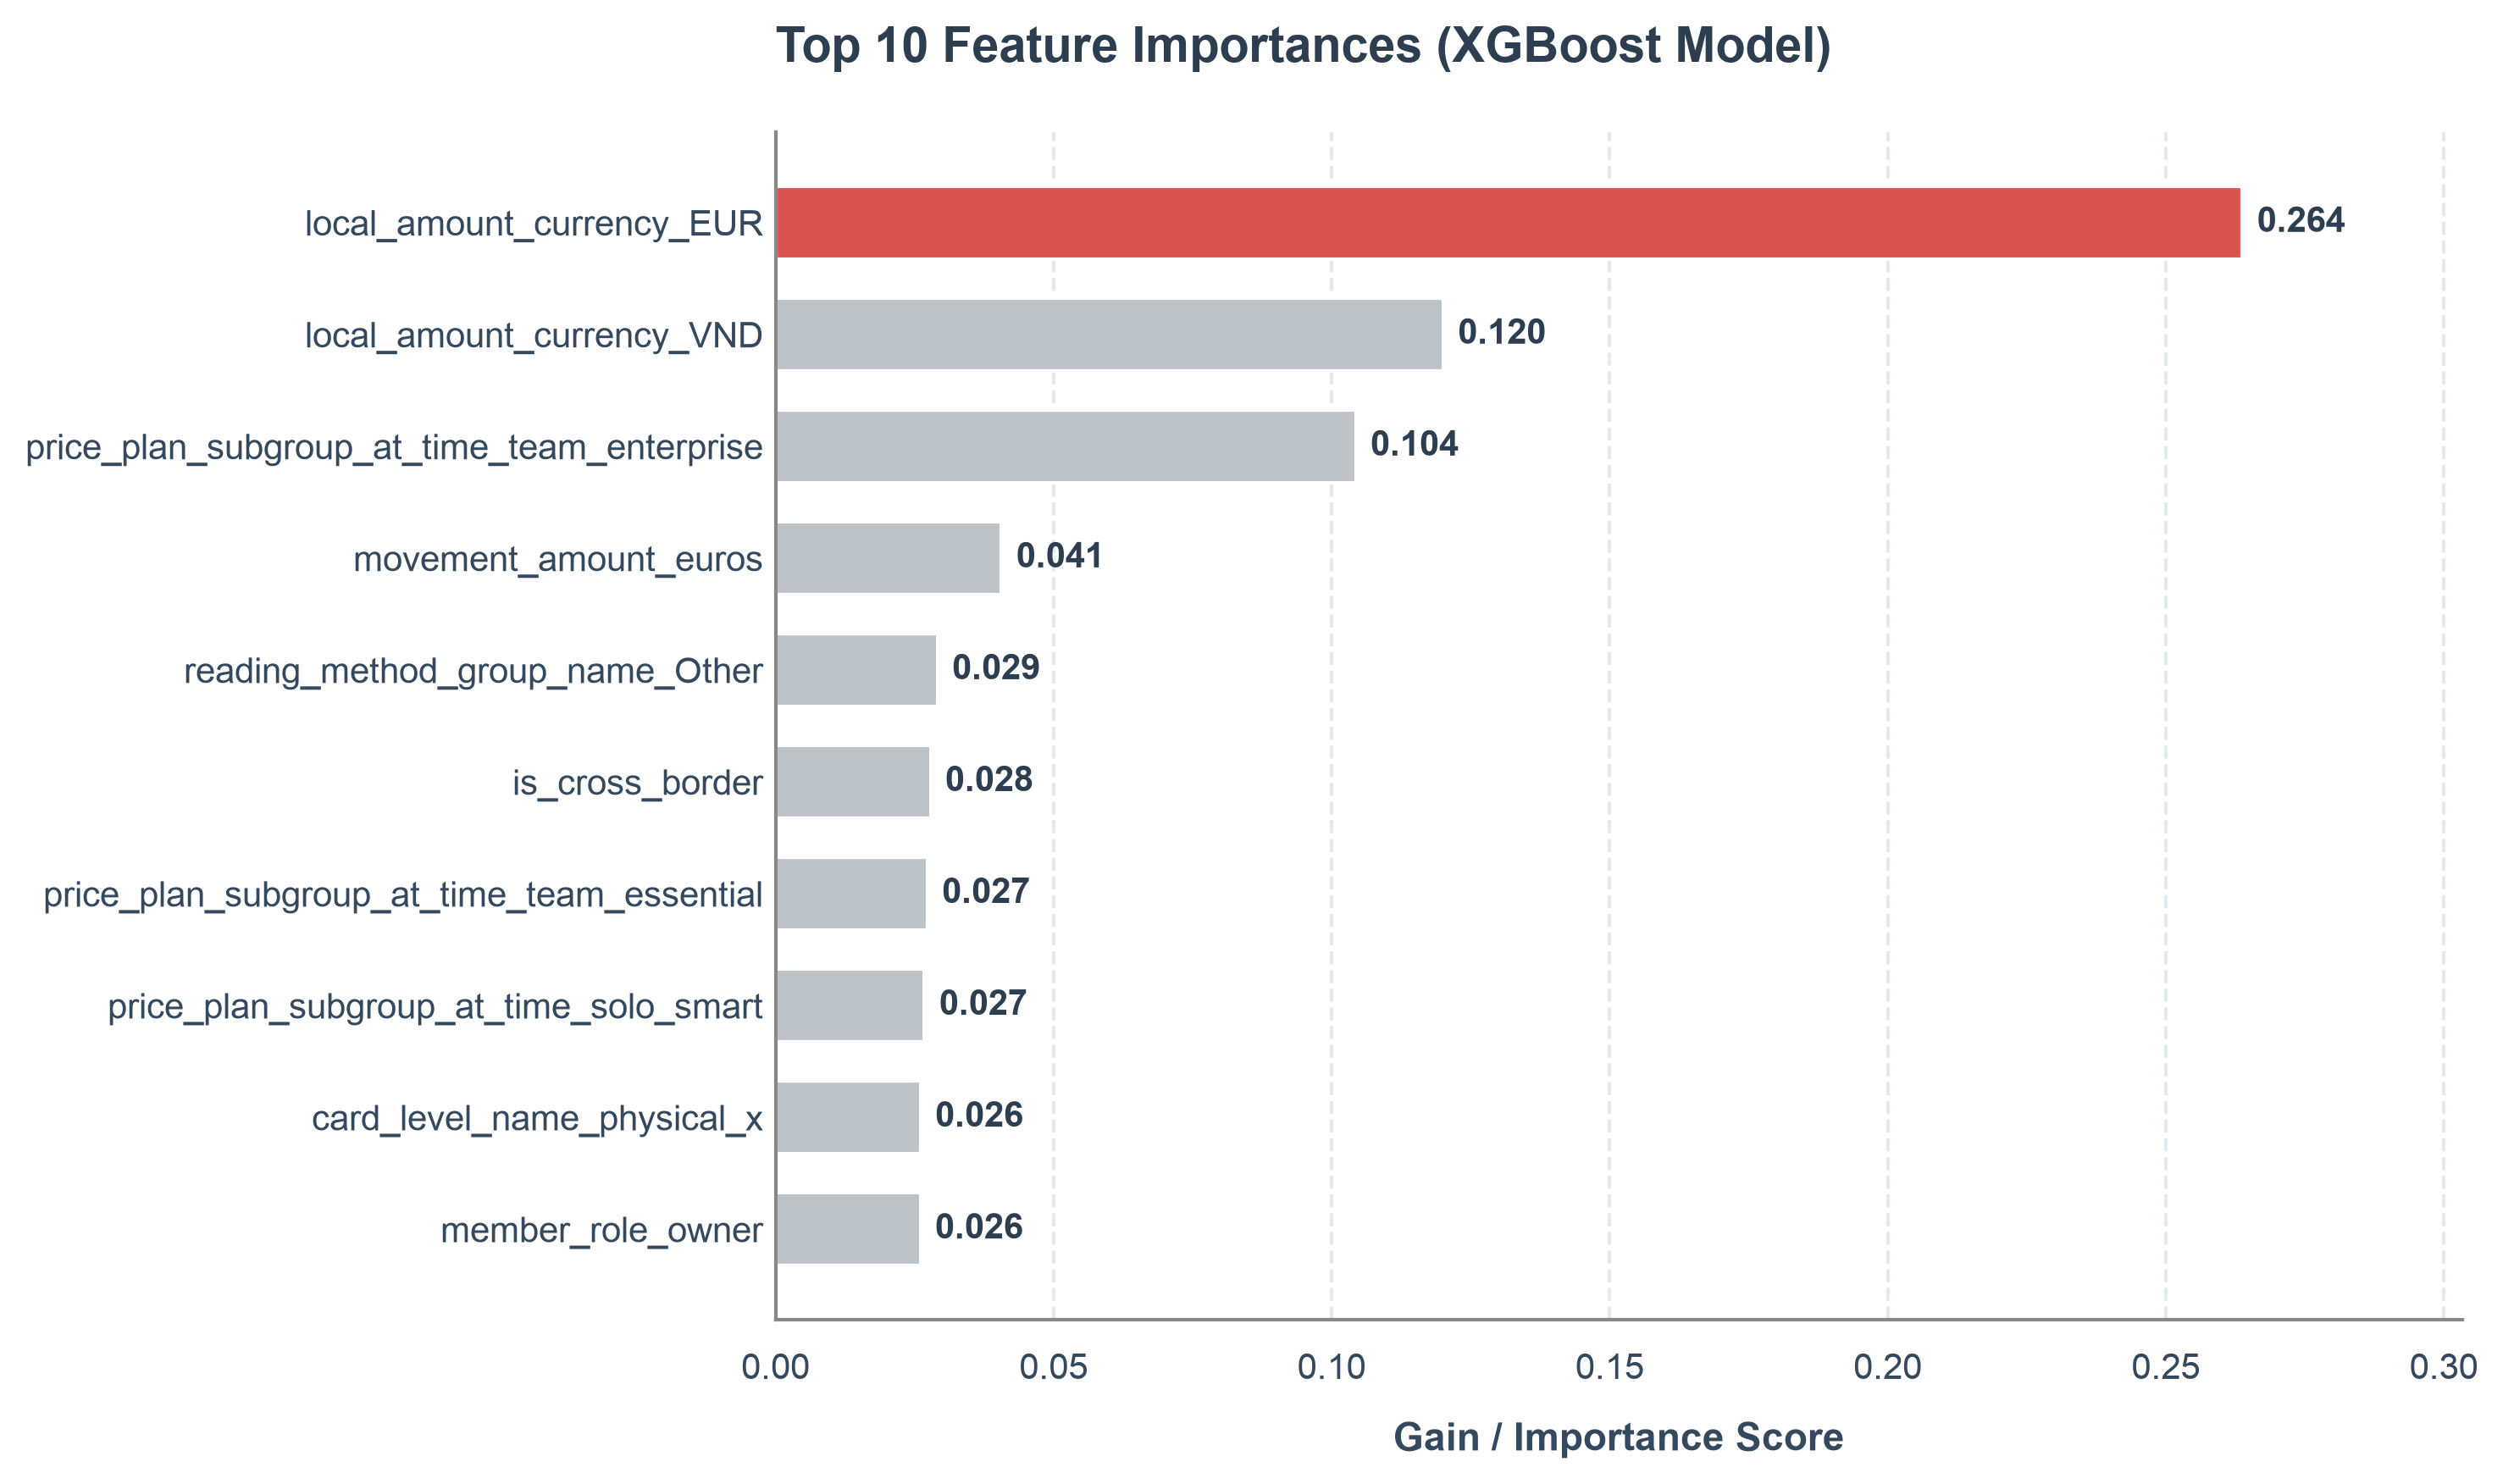

In [15]:
# 1. Extract Top 10 Features
feat_imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
df_feat = pd.DataFrame({'Feature': feat_imp.index, 'Importance': feat_imp.values}).sort_values('Importance', ascending=True)

# 2. Setup Figure & Theme
sns.set_theme(style='white')
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# 3. Custom Palette (Highlight #1 feature in red, soft neutral for others)
colors = ['#BDC3C7'] * 9 + ['#D9534F'] 

# Set zorder=2 for bars so they sit cleanly on top of gridlines (zorder=1)
bars = ax.barh(df_feat['Feature'], df_feat['Importance'], color=colors, height=0.65, zorder=2)

# 4. Add Direct Value Labels on Bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (df_feat['Importance'].max() * 0.01), 
        bar.get_y() + bar.get_height()/2, 
        f'{width:.3f}', 
        va='center', 
        ha='left', 
        fontsize=10, 
        fontweight='semibold', 
        color='#2C3E50',
        zorder=3
    )

# 5. Styling Headers & Axes
ax.set_title('Top 10 Feature Importances (XGBoost Model)', fontsize=14, fontweight='bold', pad=20, loc='left', color='#2C3E50')
ax.set_xlabel('Gain / Importance Score', fontsize=11, fontweight='semibold', color='#34495E', labelpad=10)
ax.set_ylabel('')

# Extend X limit slightly for text annotations
ax.set_xlim(0, df_feat['Importance'].max() * 1.15)

# 6. Grid & Border Adjustments
# Vertical grid lines behind the bars
ax.grid(True, axis='x', linestyle='--', alpha=0.5, color='#CBD5E1', zorder=1)

# Keep Left and Bottom spines, remove Top and Right
sns.despine(top=True, right=True, left=False, bottom=False)

# KEY FIX: Force spines to draw on top of everything (zorder=5) with clean gray styling
for spine_name in ['left', 'bottom']:
    ax.spines[spine_name].set_zorder(5)
    ax.spines[spine_name].set_color('#888888')
    ax.spines[spine_name].set_linewidth(1.0)

# Tick formatting
ax.tick_params(axis='x', rotation=0, labelsize=10, colors='#34495E')
ax.tick_params(axis='y', length=0, labelsize=10, colors='#34495E')

plt.tight_layout()

# Save for Slides
plt.savefig('feature_importance_bar_clean.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight semibold, now using 700.


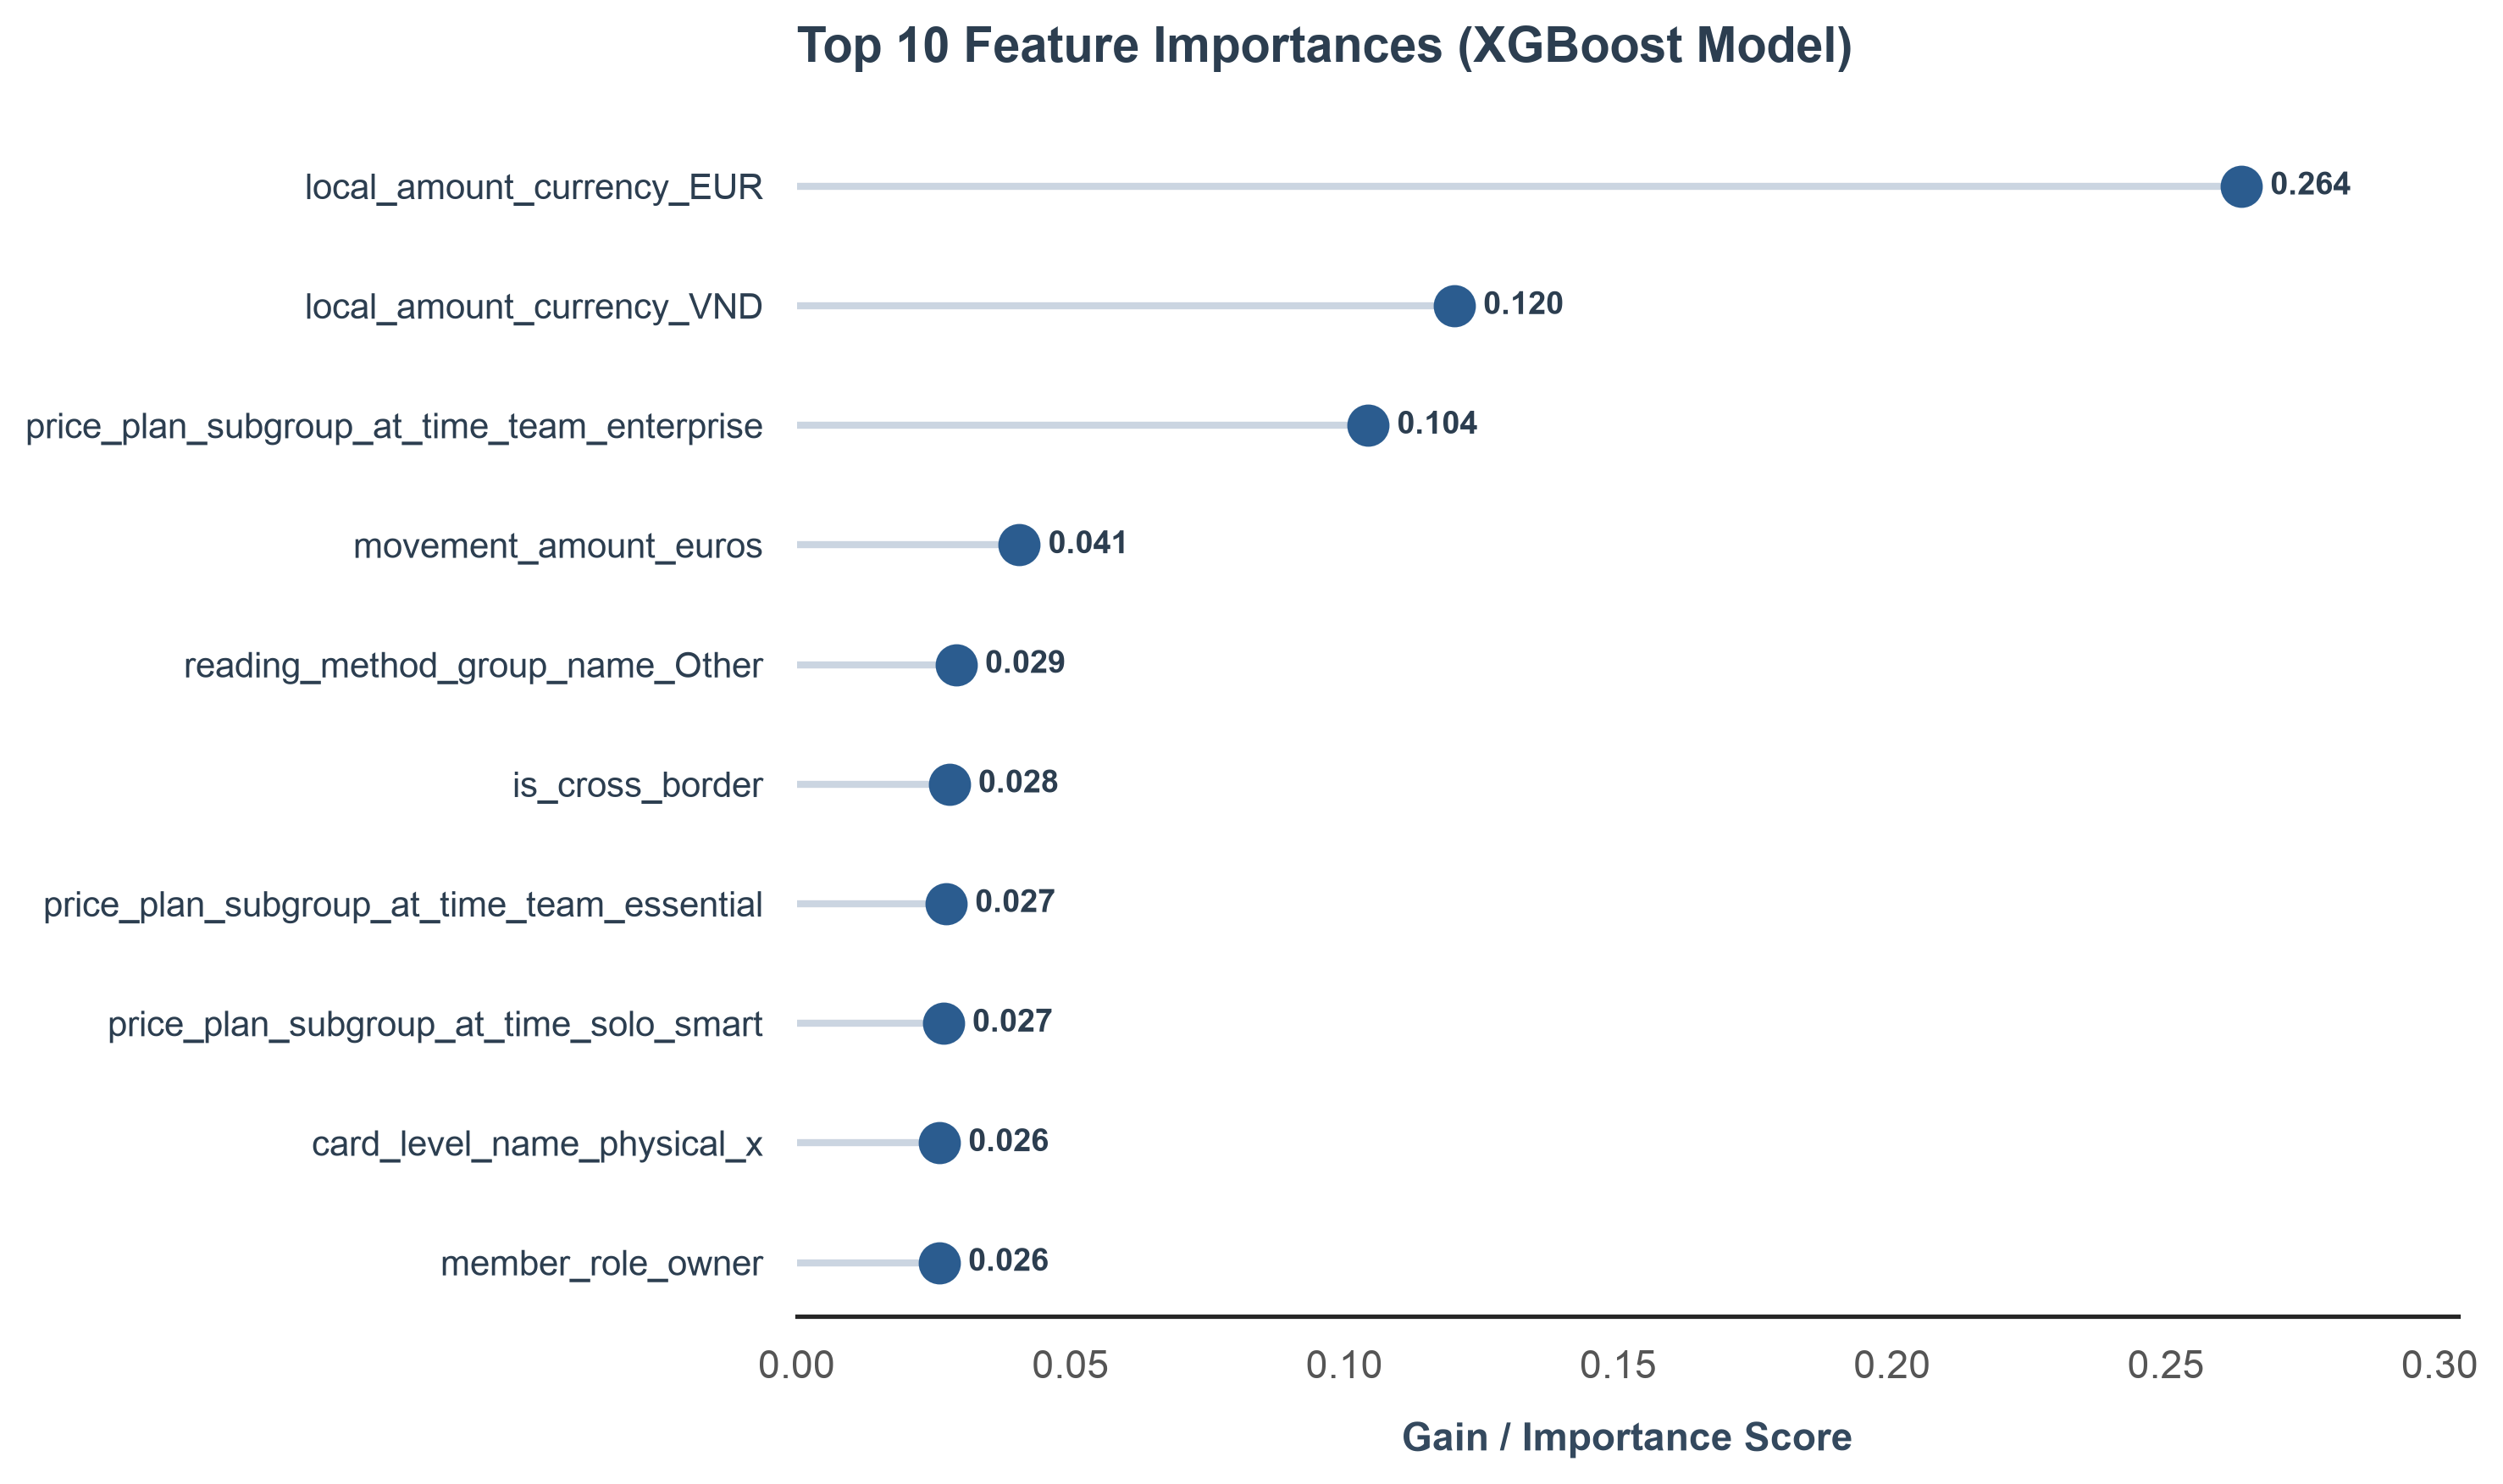

In [16]:
# 1. Extract Top 10 Features
feat_imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
df_feat = pd.DataFrame({'Feature': feat_imp.index, 'Importance': feat_imp.values}).sort_values('Importance', ascending=True)

# 2. Setup Figure
sns.set_theme(style='white')
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

y_range = range(1, len(df_feat) + 1)

# 3. Draw Stems and Dots
ax.hlines(y=y_range, xmin=0, xmax=df_feat['Importance'], color='#CBD5E1', alpha=1, linewidth=2)
ax.scatter(df_feat['Importance'], y_range, color='#2B5C8F', s=120, zorder=3)

# 4. Add Value Annotations next to Dots
for y, x in zip(y_range, df_feat['Importance']):
    ax.text(x + (df_feat['Importance'].max() * 0.02), y, f'{x:.3f}', va='center', fontsize=9, fontweight='semibold', color='#2C3E50')

# 5. Set Ticks & Titles
ax.set_yticks(y_range)
ax.set_yticklabels(df_feat['Feature'], fontsize=10, fontweight='medium', color='#2C3E50')
ax.set_title('Top 10 Feature Importances (XGBoost Model)', fontsize=14, fontweight='bold', pad=20, loc='left', color='#2C3E50')
ax.set_xlabel('Gain / Importance Score', fontsize=11, fontweight='semibold', color='#34495E', labelpad=10)

ax.set_xlim(0, df_feat['Importance'].max() * 1.15)

# Clean Spines
sns.despine(top=True, right=True, left=True, bottom=False)
ax.grid(False)
ax.tick_params(axis='x', colors='#555555')

plt.tight_layout()

# Export for Slides
plt.savefig('feature_importance_lollipop.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

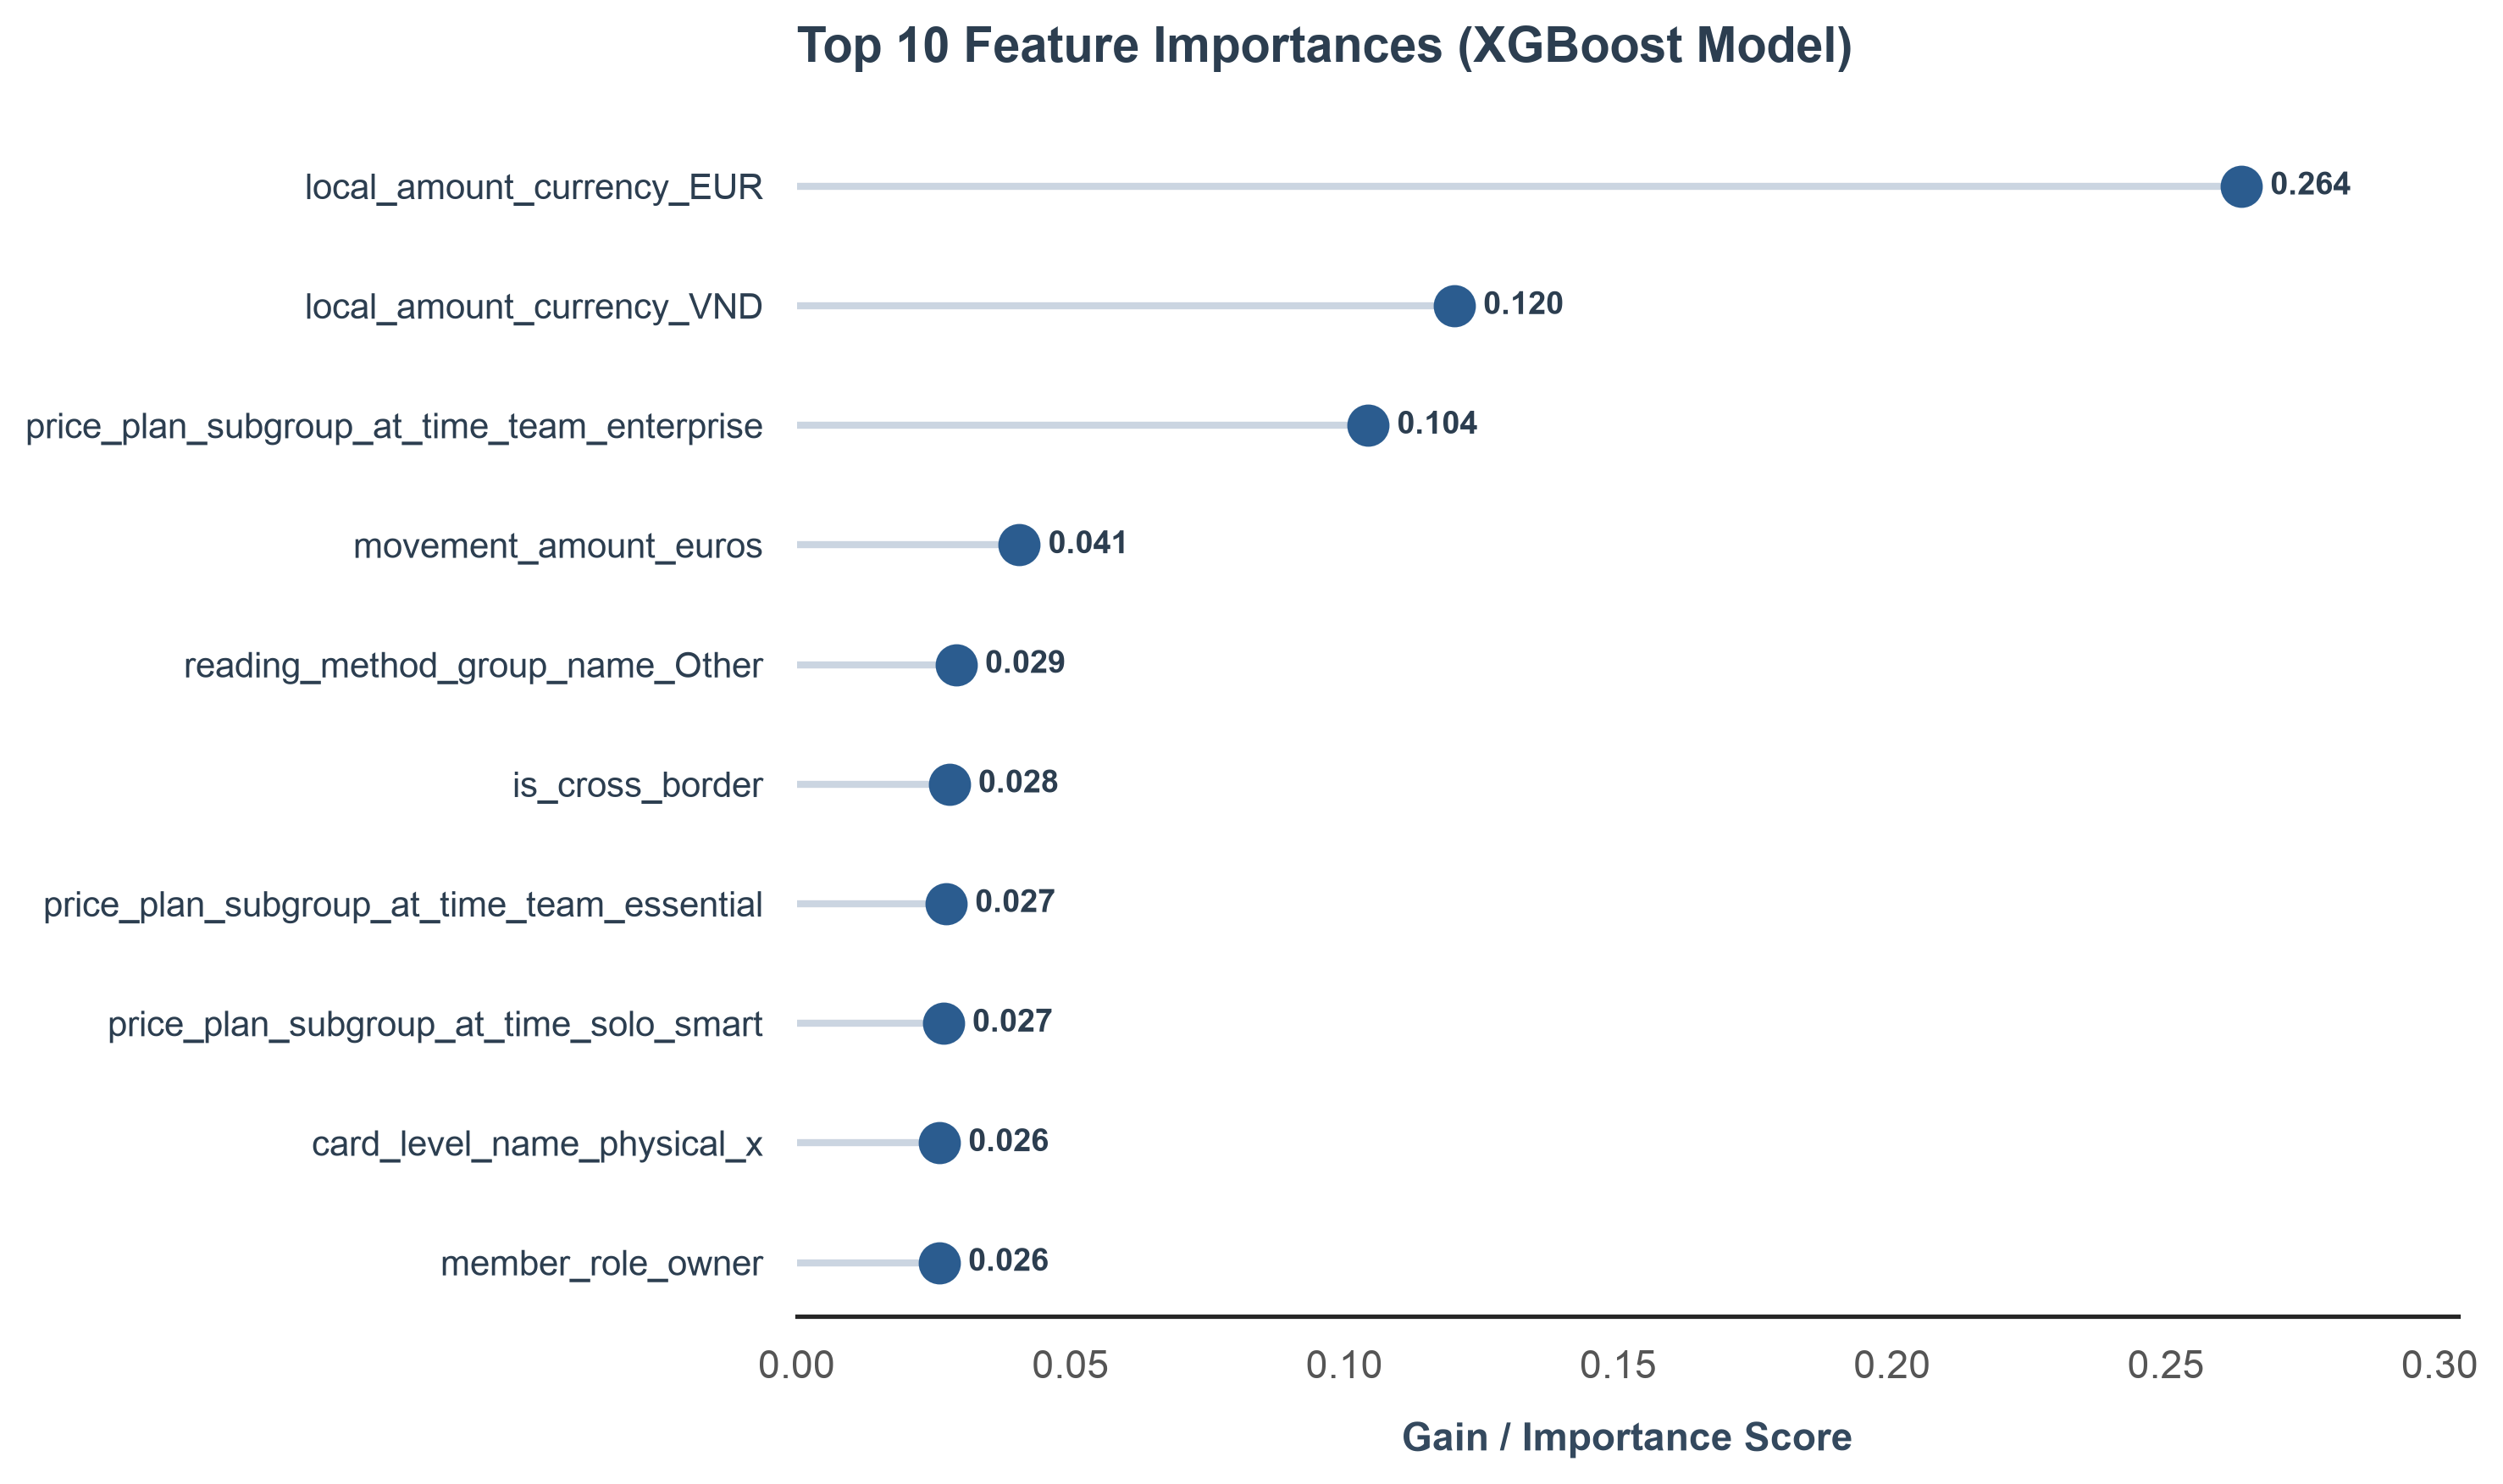

In [17]:
# 1. Extract Top 10 Features
feat_imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
df_feat = pd.DataFrame({'Feature': feat_imp.index, 'Importance': feat_imp.values}).sort_values('Importance', ascending=True)

# 2. Setup Figure
sns.set_theme(style='white')
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

y_range = range(1, len(df_feat) + 1)

# 3. Draw Stems and Dots
ax.hlines(y=y_range, xmin=0, xmax=df_feat['Importance'], color='#CBD5E1', alpha=1, linewidth=2)
ax.scatter(df_feat['Importance'], y_range, color='#2B5C8F', s=120, zorder=3)

# 4. Add Value Annotations next to Dots
for y, x in zip(y_range, df_feat['Importance']):
    ax.text(x + (df_feat['Importance'].max() * 0.02), y, f'{x:.3f}', va='center', fontsize=9, fontweight='semibold', color='#2C3E50')

# 5. Set Ticks & Titles
ax.set_yticks(y_range)
ax.set_yticklabels(df_feat['Feature'], fontsize=10, fontweight='medium', color='#2C3E50')
ax.set_title('Top 10 Feature Importances (XGBoost Model)', fontsize=14, fontweight='bold', pad=20, loc='left', color='#2C3E50')
ax.set_xlabel('Gain / Importance Score', fontsize=11, fontweight='semibold', color='#34495E', labelpad=10)

ax.set_xlim(0, df_feat['Importance'].max() * 1.15)

# Clean Spines
sns.despine(top=True, right=True, left=True, bottom=False)
ax.grid(False)
ax.tick_params(axis='x', colors='#555555')

plt.tight_layout()

# Export for Slides
plt.savefig('feature_importance_lollipop.png', bbox_inches='tight', dpi=300, facecolor='white')
plt.show()